# Time-Series Clustering

The objective of this notebook is to cluster the preprocessed time-series windows using time-series-aware methods and appropriate distances.

Following the project requirements, we apply at least two clustering configurations and compare their results. The analysis is performed on the PAA approximation of the window-wise standardized multivariate time series, using the six selected signals: `X`, `Y`, `Z`, `enmo`, `anglez`, and `light`.

The PAA representation reduces each time series from 200 to 50 time steps, making distance-based clustering computationally feasible while preserving the main temporal structure.

In [1]:
# Imports

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering

from sktime.clustering.k_means import TimeSeriesKMeans

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load preprocessed time-series dataset

with open("../dataset/CMI_timeseries_dataset.pkl", "rb") as f:
    CMI_timeseries_dataset = pickle.load(f)

print("Number of time-series windows:", len(CMI_timeseries_dataset))
print("Example window shape:", CMI_timeseries_dataset[0].shape)
print("Example columns:")
print(CMI_timeseries_dataset[0].columns.tolist())

Number of time-series windows: 4437
Example window shape: (200, 13)
Example columns:
['X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'battery_voltage', 'weekday', 'quarter', 'relative_date_PCIAT', 'id', 'sii_binary']


In [3]:
# Load PAA and SAX approximation outputs

with open("../dataset/CMI_timeseries_approximation_outputs.pkl", "rb") as f:
    approximation_output = pickle.load(f)

X_paa_global = approximation_output["X_paa_global"]
X_paa_subject = approximation_output["X_paa_subject"]
sax_df = approximation_output["sax_df"]

signal_cols = approximation_output["signal_cols"]
id_col = approximation_output["id_col"]
target_col = approximation_output["target_col"]

print("Global-scaled PAA shape:", X_paa_global.shape)
print("Window-wise-scaled PAA shape:", X_paa_subject.shape)
print("Signal columns:", signal_cols)

Global-scaled PAA shape: (4310, 50, 6)
Window-wise-scaled PAA shape: (4310, 50, 6)
Signal columns: ['X', 'Y', 'Z', 'enmo', 'anglez', 'light']


In [4]:
# Build metadata dataframe for the time-series windows

metadata_rows = []

for i, ts_df in enumerate(CMI_timeseries_dataset):
    metadata_rows.append({
        "series_index": i,
        "subject_id": ts_df[id_col].iloc[0],
        "target": ts_df[target_col].iloc[0]
    })

metadata_df = pd.DataFrame(metadata_rows)

print("Metadata shape:", metadata_df.shape)
display(metadata_df.head())

print("Target distribution:")
display(metadata_df["target"].value_counts().sort_index())

Metadata shape: (4437, 3)


,series_index,subject_id,target
0,0,2265,0
1,1,51,1
2,2,3042,1
3,3,1647,1
4,4,736,0


Target distribution:


target
0    2957
1    1480
Name: count, dtype: int64

In [5]:
# Prepare PAA data for sktime clustering

# X_paa_subject has shape: n_windows × n_time_steps × n_signals
# sktime expects: n_windows × n_channels × n_time_steps

X_cluster = np.transpose(X_paa_subject, (0, 2, 1))

print("Clustering input shape:", X_cluster.shape)
print("Format: n_windows × n_channels × n_time_steps")

Clustering input shape: (4310, 6, 50)
Format: n_windows × n_channels × n_time_steps


In [9]:
# Check available time-series dataset variables

candidate_names = [
    "CMI_timeseries_dataset",
    "CMI_timeseries_filtered",
    "CMI_timeseries_global_scaled",
    "CMI_timeseries_subject_scaled",
    "X_paa_global",
    "X_paa_subject",
    "X_cluster"
]

for name in candidate_names:
    if name in globals():
        obj = globals()[name]
        try:
            print(name, "length/shape:", len(obj), getattr(obj, "shape", None))
        except TypeError:
            print(name, "shape:", getattr(obj, "shape", None))

CMI_timeseries_dataset length/shape: 4437 None
X_paa_global length/shape: 4310 (4310, 50, 6)
X_paa_subject length/shape: 4310 (4310, 50, 6)
X_cluster length/shape: 4310 (4310, 6, 50)


In [11]:
# Check available variables related to time series / PAA / scaled data

for name in sorted(globals().keys()):
    if (
        "time" in name.lower()
        or "paa" in name.lower()
        or "scaled" in name.lower()
        or "cluster" in name.lower()
        or "cmi" in name.lower()
    ):
        obj = globals()[name]
        try:
            print(f"{name}: type={type(obj)}, len={len(obj)}, shape={getattr(obj, 'shape', None)}")
        except Exception:
            print(f"{name}: type={type(obj)}, shape={getattr(obj, 'shape', None)}")

AgglomerativeClustering: type=<class 'type'>, shape=None
CMI_timeseries_dataset: type=<class 'list'>, len=4437, shape=None
TimeSeriesKMeans: type=<class 'type'>, shape=None
X_cluster: type=<class 'numpy.ndarray'>, len=4310, shape=(4310, 6, 50)
X_paa_global: type=<class 'numpy.ndarray'>, len=4310, shape=(4310, 50, 6)
X_paa_subject: type=<class 'numpy.ndarray'>, len=4310, shape=(4310, 50, 6)


In [12]:
# Load metadata aligned with filtered / PAA datasets

metadata_df = pd.read_pickle("../dataset/CMI_timeseries_metadata_filtered.pkl")

assert len(metadata_df) == X_cluster.shape[0], (
    f"metadata length={len(metadata_df)}, X_cluster length={X_cluster.shape[0]}"
)

print("Metadata shape:", metadata_df.shape)
print("X_cluster shape:", X_cluster.shape)
display(metadata_df.head())

print("Target distribution:")
display(metadata_df["target"].value_counts().sort_index())

Metadata shape: (4310, 3)
X_cluster shape: (4310, 6, 50)


,window_pos,subject_id,target
0,0,2265,0
1,1,3042,1
2,2,1647,1
3,3,736,0
4,4,1044,0


Target distribution:


target
0    2888
1    1422
Name: count, dtype: int64

## Distance-based time-series clustering

We apply distance-based time-series clustering using `TimeSeriesKMeans` with two distances: Euclidean distance and Dynamic Time Warping (DTW).

Euclidean distance provides a simple baseline and compares time series point by point. This is reasonable because all time-series windows have the same length and were transformed into the same PAA representation.

DTW is more flexible because it allows local temporal misalignments between time series. This is useful when similar activity patterns occur at slightly different time positions within different windows.

Since clustering is unsupervised, the number of clusters is not fixed a priori. We evaluate several values of \(k\) using internal clustering scores. The target labels are used only after clustering, to interpret the relationship between clusters and the binary outcome.

In [14]:
# Stratified sample for computationally feasible clustering

n_per_class = 300
random_state = 42

sample_positions = []

for cls in sorted(metadata_df["target"].unique()):
    cls_positions = metadata_df.loc[
        metadata_df["target"] == cls,
        "window_pos"
    ]

    sampled = cls_positions.sample(
        n=min(n_per_class, len(cls_positions)),
        random_state=random_state
    ).tolist()

    sample_positions.extend(sampled)

sample_positions = sorted(sample_positions)

X_cluster_sample = X_cluster[sample_positions]

metadata_sample_df = (
    metadata_df
    .set_index("window_pos")
    .loc[sample_positions]
    .reset_index()
)

y_sample = metadata_sample_df["target"].to_numpy()

print("Sampled clustering input shape:", X_cluster_sample.shape)
print("Sample metadata shape:", metadata_sample_df.shape)

print("Sample target distribution:")
display(metadata_sample_df["target"].value_counts().sort_index())

print("Max sampled position:", max(sample_positions))
print("X_cluster first axis size:", X_cluster.shape[0])

Sampled clustering input shape: (600, 6, 50)
Sample metadata shape: (600, 3)
Sample target distribution:


target
0    300
1    300
Name: count, dtype: int64

Max sampled position: 4307
X_cluster first axis size: 4310


In [15]:
# Flatten sampled PAA time series for evaluation and dimensionality reduction

X_sample_flat = X_cluster_sample.reshape(X_cluster_sample.shape[0], -1)

print("Original sampled shape:", X_cluster_sample.shape)
print("Flattened sampled shape:", X_sample_flat.shape)

Original sampled shape: (600, 6, 50)
Flattened sampled shape: (600, 300)


In [16]:
# Evaluate TimeSeriesKMeans with Euclidean distance for different k values

k_values = [2, 3, 4, 5, 6]
random_state = 42

euclidean_results = []

for k in k_values:
    print(f"Fitting Euclidean TimeSeriesKMeans with k={k}...")
    
    model = TimeSeriesKMeans(
        n_clusters=k,
        metric="euclidean",
        random_state=random_state,
        n_init=5
    )
    
    labels = model.fit_predict(X_cluster_sample)
    
    sil = silhouette_score(X_sample_flat, labels)
    ari = adjusted_rand_score(y_sample, labels)
    nmi = normalized_mutual_info_score(y_sample, labels)
    
    euclidean_results.append({
        "k": k,
        "silhouette": sil,
        "ARI_vs_target": ari,
        "NMI_vs_target": nmi,
        "labels": labels,
        "model": model
    })

euclidean_results_df = pd.DataFrame([
    {key: value for key, value in row.items() if key not in ["labels", "model"]}
    for row in euclidean_results
])

display(euclidean_results_df)

Fitting Euclidean TimeSeriesKMeans with k=2...
Fitting Euclidean TimeSeriesKMeans with k=3...
Fitting Euclidean TimeSeriesKMeans with k=4...
Fitting Euclidean TimeSeriesKMeans with k=5...
Fitting Euclidean TimeSeriesKMeans with k=6...


,k,silhouette,ARI_vs_target,NMI_vs_target
0,2,0.032491,-0.000316,0.000978
1,3,0.026535,0.003548,0.004797
2,4,0.020667,-0.000540,0.001856
3,5,0.019326,0.004313,0.007359
4,6,0.019489,0.000712,0.004131


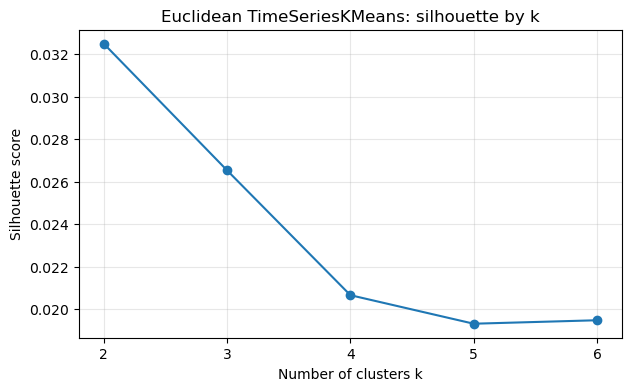

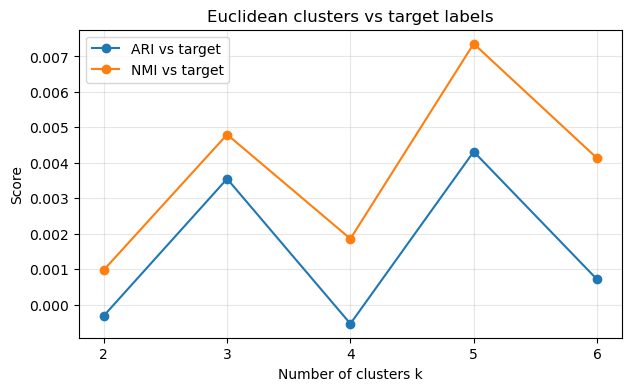

In [17]:
# Plot Euclidean clustering evaluation across k values

plt.figure(figsize=(7, 4))
plt.plot(
    euclidean_results_df["k"],
    euclidean_results_df["silhouette"],
    marker="o"
)
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Euclidean TimeSeriesKMeans: silhouette by k")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(
    euclidean_results_df["k"],
    euclidean_results_df["ARI_vs_target"],
    marker="o",
    label="ARI vs target"
)
plt.plot(
    euclidean_results_df["k"],
    euclidean_results_df["NMI_vs_target"],
    marker="o",
    label="NMI vs target"
)
plt.xlabel("Number of clusters k")
plt.ylabel("Score")
plt.title("Euclidean clusters vs target labels")
plt.xticks(k_values)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
# Select Euclidean k with highest silhouette score

best_euclidean_row = euclidean_results_df.loc[
    euclidean_results_df["silhouette"].idxmax()
]

best_k_euclidean = int(best_euclidean_row["k"])

best_euclidean_result = next(
    row for row in euclidean_results
    if row["k"] == best_k_euclidean
)

euclidean_labels = best_euclidean_result["labels"]
euclidean_model = best_euclidean_result["model"]

metadata_sample_df["cluster_euclidean"] = euclidean_labels

print("Best Euclidean k based on silhouette:", best_k_euclidean)
display(best_euclidean_row)

Best Euclidean k based on silhouette: 2


k                2.000000
silhouette       0.032491
ARI_vs_target   -0.000316
NMI_vs_target    0.000978
Name: 0, dtype: float64

In [19]:
# Interpret Euclidean clusters using target labels

euclidean_cluster_counts = pd.crosstab(
    metadata_sample_df["cluster_euclidean"],
    metadata_sample_df["target"]
)

euclidean_cluster_props = pd.crosstab(
    metadata_sample_df["cluster_euclidean"],
    metadata_sample_df["target"],
    normalize="index"
)

print("Euclidean cluster counts by target:")
display(euclidean_cluster_counts)

print("Euclidean cluster proportions by target:")
display(euclidean_cluster_props)

Euclidean cluster counts by target:


target,0,1
cluster_euclidean,,
0,167,156
1,133,144


Euclidean cluster proportions by target:


target,0,1
cluster_euclidean,,
0,0.517028,0.482972
1,0.480144,0.519856


In [20]:
# Evaluate TimeSeriesKMeans with DTW distance for different k values

k_values_dtw = [2, 3, 4, 5]
random_state = 42

dtw_results = []

for k in k_values_dtw:
    print(f"Fitting DTW TimeSeriesKMeans with k={k}...")
    
    model = TimeSeriesKMeans(
        n_clusters=k,
        metric="dtw",
        random_state=random_state,
        n_init=2
    )
    
    labels = model.fit_predict(X_cluster_sample)
    
    # Approximate internal evaluation on flattened PAA representation
    sil = silhouette_score(X_sample_flat, labels)
    ari = adjusted_rand_score(y_sample, labels)
    nmi = normalized_mutual_info_score(y_sample, labels)
    
    dtw_results.append({
        "k": k,
        "silhouette_flat": sil,
        "ARI_vs_target": ari,
        "NMI_vs_target": nmi,
        "labels": labels,
        "model": model
    })

dtw_results_df = pd.DataFrame([
    {key: value for key, value in row.items() if key not in ["labels", "model"]}
    for row in dtw_results
])

display(dtw_results_df)

Fitting DTW TimeSeriesKMeans with k=2...
Fitting DTW TimeSeriesKMeans with k=3...
Fitting DTW TimeSeriesKMeans with k=4...
Fitting DTW TimeSeriesKMeans with k=5...


,k,silhouette_flat,ARI_vs_target,NMI_vs_target
0,2,0.031335,0.003716,0.003887
1,3,0.025579,0.000351,0.002211
2,4,0.019975,-0.001491,0.000951
3,5,0.018561,-0.002175,0.000536


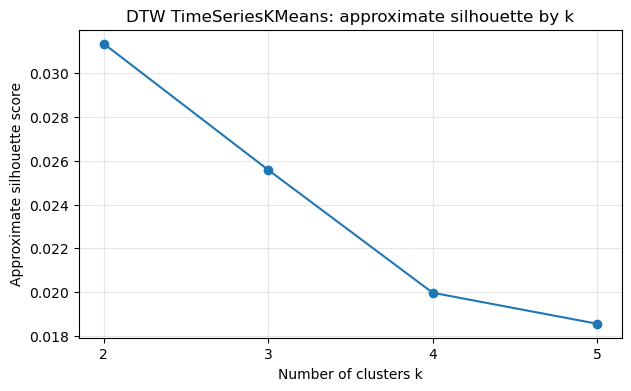

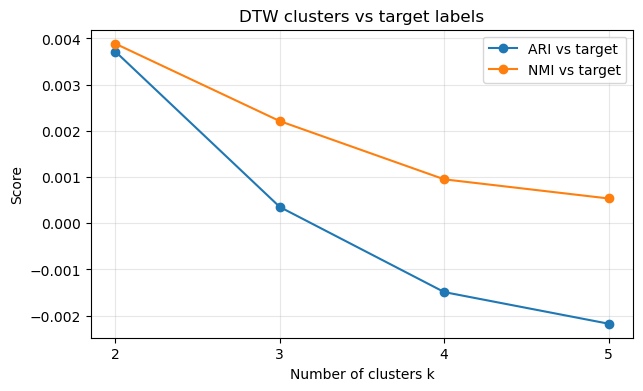

In [21]:
# Plot DTW clustering evaluation across k values

plt.figure(figsize=(7, 4))
plt.plot(
    dtw_results_df["k"],
    dtw_results_df["silhouette_flat"],
    marker="o"
)
plt.xlabel("Number of clusters k")
plt.ylabel("Approximate silhouette score")
plt.title("DTW TimeSeriesKMeans: approximate silhouette by k")
plt.xticks(k_values_dtw)
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(
    dtw_results_df["k"],
    dtw_results_df["ARI_vs_target"],
    marker="o",
    label="ARI vs target"
)
plt.plot(
    dtw_results_df["k"],
    dtw_results_df["NMI_vs_target"],
    marker="o",
    label="NMI vs target"
)
plt.xlabel("Number of clusters k")
plt.ylabel("Score")
plt.title("DTW clusters vs target labels")
plt.xticks(k_values_dtw)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [22]:
# Select DTW k with highest approximate silhouette score

best_dtw_row = dtw_results_df.loc[
    dtw_results_df["silhouette_flat"].idxmax()
]

best_k_dtw = int(best_dtw_row["k"])

best_dtw_result = next(
    row for row in dtw_results
    if row["k"] == best_k_dtw
)

dtw_labels = best_dtw_result["labels"]
dtw_model = best_dtw_result["model"]

metadata_sample_df["cluster_dtw"] = dtw_labels

print("Best DTW k based on approximate silhouette:", best_k_dtw)
display(best_dtw_row)

Best DTW k based on approximate silhouette: 2


k                  2.000000
silhouette_flat    0.031335
ARI_vs_target      0.003716
NMI_vs_target      0.003887
Name: 0, dtype: float64

In [23]:
# Interpret DTW clusters using target labels

dtw_cluster_counts = pd.crosstab(
    metadata_sample_df["cluster_dtw"],
    metadata_sample_df["target"]
)

dtw_cluster_props = pd.crosstab(
    metadata_sample_df["cluster_dtw"],
    metadata_sample_df["target"],
    normalize="index"
)

print("DTW cluster counts by target:")
display(dtw_cluster_counts)

print("DTW cluster proportions by target:")
display(dtw_cluster_props)

DTW cluster counts by target:


target,0,1
cluster_dtw,,
0,143,165
1,157,135


DTW cluster proportions by target:


target,0,1
cluster_dtw,,
0,0.464286,0.535714
1,0.537671,0.462329


In [24]:
# Compare Euclidean and DTW clustering assignments

cluster_comparison = pd.crosstab(
    metadata_sample_df["cluster_euclidean"],
    metadata_sample_df["cluster_dtw"]
)

ari_euclidean_dtw = adjusted_rand_score(
    metadata_sample_df["cluster_euclidean"],
    metadata_sample_df["cluster_dtw"]
)

nmi_euclidean_dtw = normalized_mutual_info_score(
    metadata_sample_df["cluster_euclidean"],
    metadata_sample_df["cluster_dtw"]
)

print("Euclidean vs DTW cluster assignment comparison:")
display(cluster_comparison)

print("ARI between Euclidean and DTW clusters:", ari_euclidean_dtw)
print("NMI between Euclidean and DTW clusters:", nmi_euclidean_dtw)

Euclidean vs DTW cluster assignment comparison:


cluster_dtw,0,1
cluster_euclidean,,
0,42,281
1,266,11


ARI between Euclidean and DTW clusters: 0.6773413138309992
NMI between Euclidean and DTW clusters: 0.5895097248478903


In [25]:
# Function to plot average cluster profiles for each signal

def plot_cluster_profiles(X_data, labels, signal_cols, title_prefix):
    """
    Plot average PAA profile by cluster for each signal.
    
    X_data shape: n_windows × n_channels × n_time_steps
    """
    unique_clusters = sorted(np.unique(labels))
    
    for signal_idx, signal in enumerate(signal_cols):
        plt.figure(figsize=(8, 4))
        
        for cluster in unique_clusters:
            cluster_mean = X_data[labels == cluster, signal_idx, :].mean(axis=0)
            plt.plot(
                cluster_mean,
                label=f"Cluster {cluster}"
            )
        
        plt.title(f"{title_prefix} - average {signal} profile by cluster")
        plt.xlabel("PAA time step")
        plt.ylabel(f"Window-wise standardized {signal}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

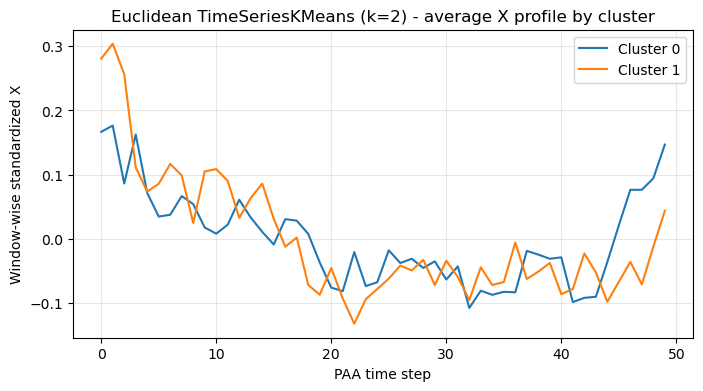

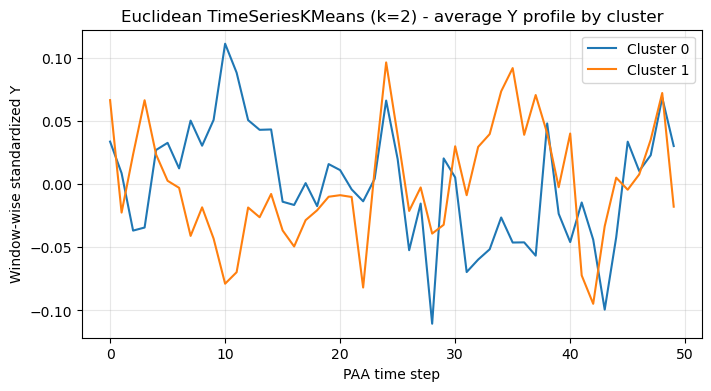

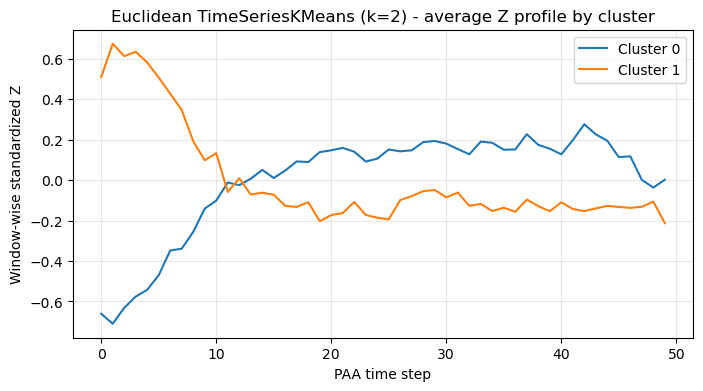

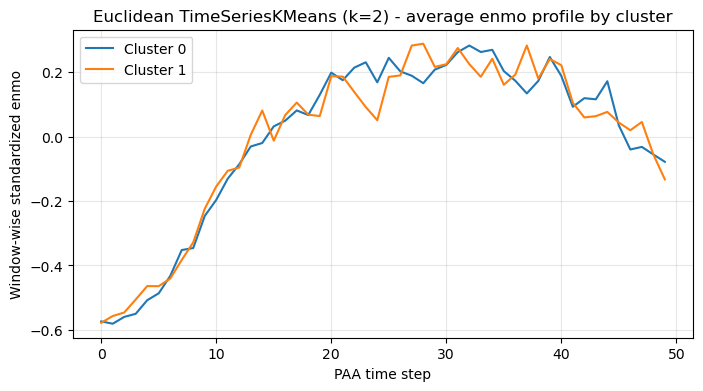

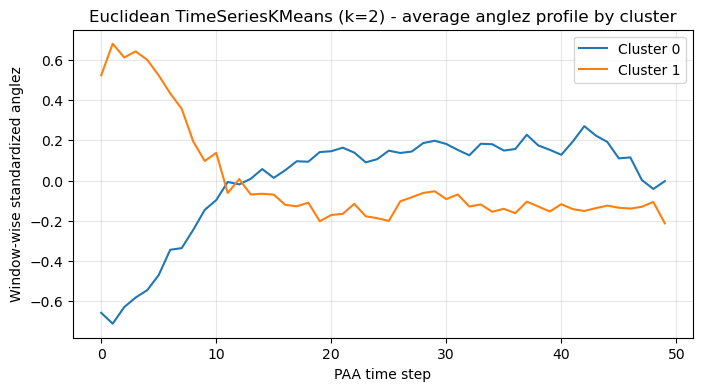

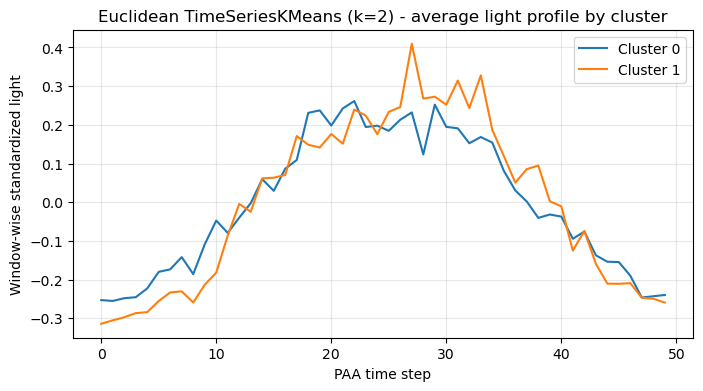

In [26]:
# Plot Euclidean cluster profiles

plot_cluster_profiles(
    X_data=X_cluster_sample,
    labels=euclidean_labels,
    signal_cols=signal_cols,
    title_prefix=f"Euclidean TimeSeriesKMeans (k={best_k_euclidean})"
)

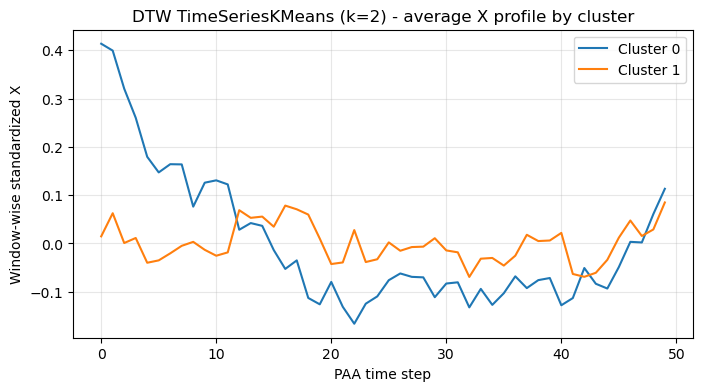

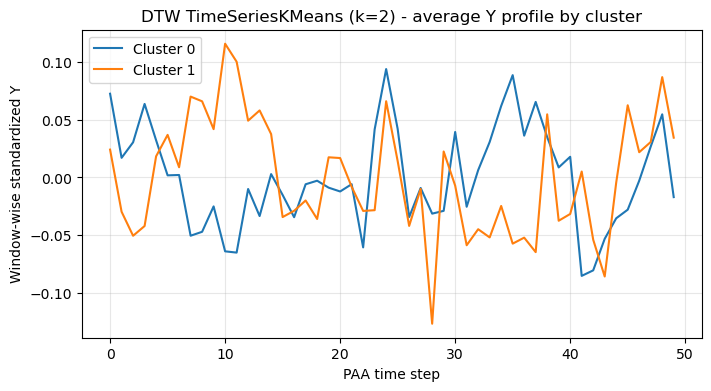

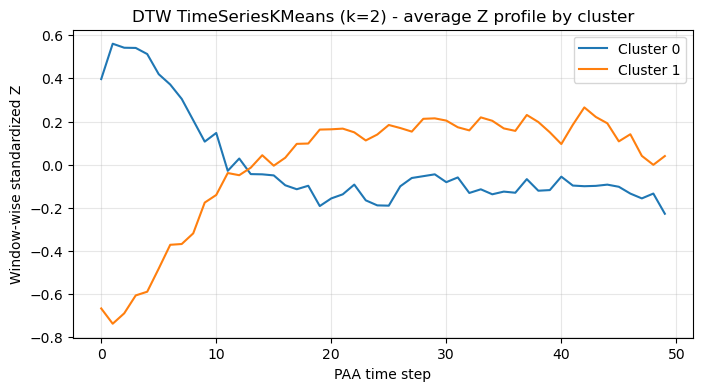

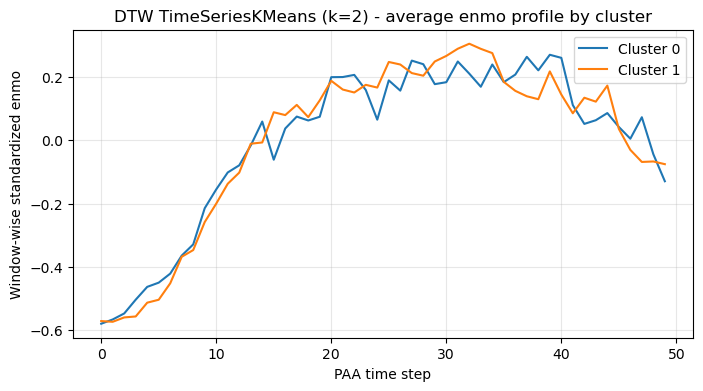

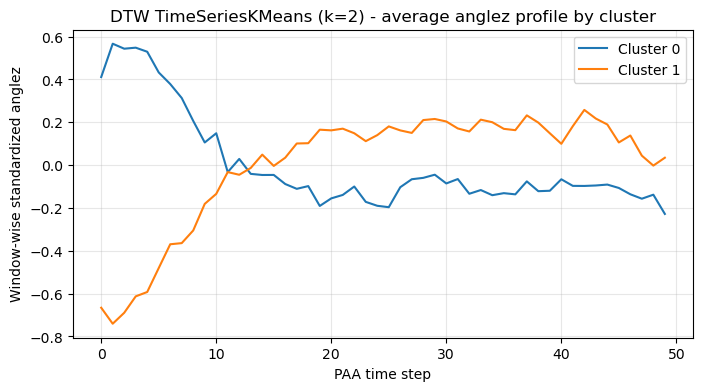

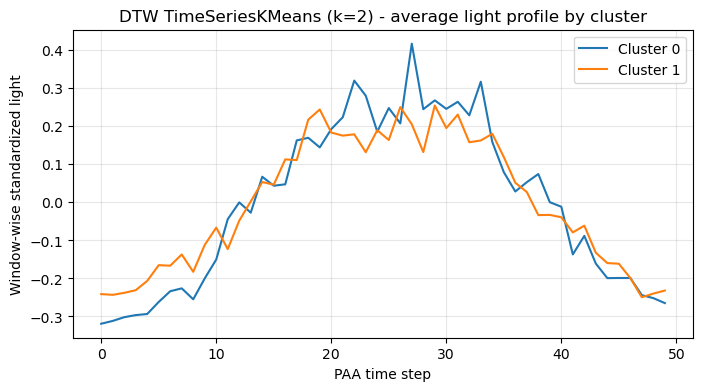

In [27]:
# Plot DTW cluster profiles

plot_cluster_profiles(
    X_data=X_cluster_sample,
    labels=dtw_labels,
    signal_cols=signal_cols,
    title_prefix=f"DTW TimeSeriesKMeans (k={best_k_dtw})"
)

Explained variance ratio: [0.05313985 0.04163066]
Total explained variance: 0.09477051


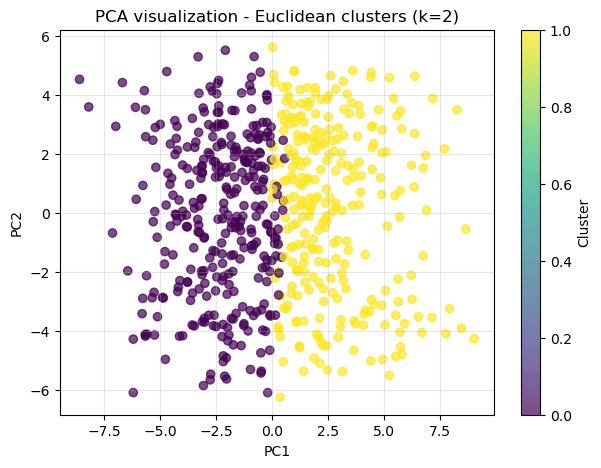

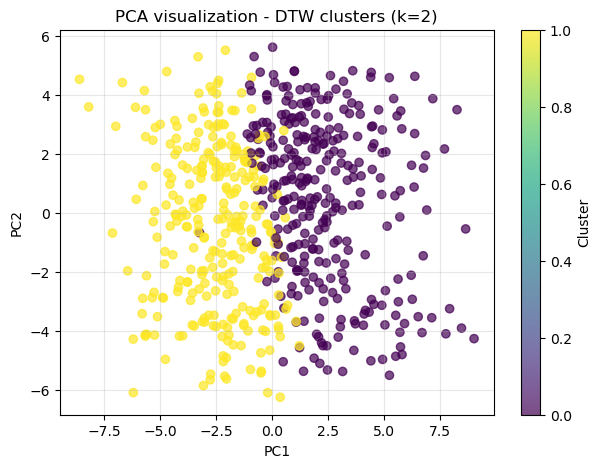

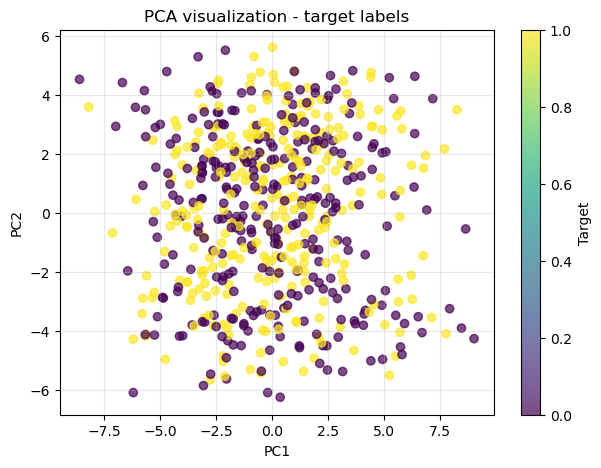

In [28]:
# PCA visualization of the clustering results

pca = PCA(n_components=2, random_state=random_state)
X_pca = pca.fit_transform(X_sample_flat)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=euclidean_labels,
    alpha=0.7
)
plt.title(f"PCA visualization - Euclidean clusters (k={best_k_euclidean})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dtw_labels,
    alpha=0.7
)
plt.title(f"PCA visualization - DTW clusters (k={best_k_dtw})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_sample,
    alpha=0.7
)
plt.title("PCA visualization - target labels")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Target")
plt.grid(alpha=0.3)
plt.show()

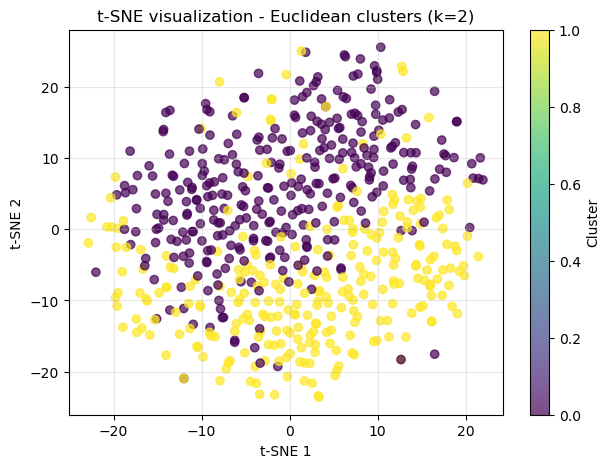

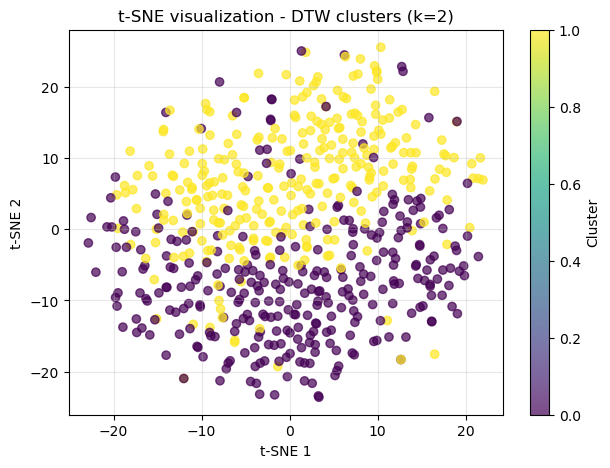

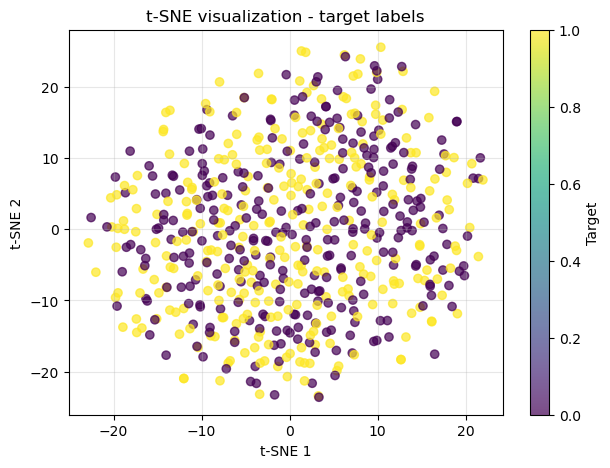

In [29]:
# t-SNE visualization of the clustering results

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=random_state
)

X_tsne = tsne.fit_transform(X_sample_flat)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=euclidean_labels,
    alpha=0.7
)
plt.title(f"t-SNE visualization - Euclidean clusters (k={best_k_euclidean})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(label="Cluster")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=dtw_labels,
    alpha=0.7
)
plt.title(f"t-SNE visualization - DTW clusters (k={best_k_dtw})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(label="Cluster")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_sample,
    alpha=0.7
)
plt.title("t-SNE visualization - target labels")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(label="Target")
plt.grid(alpha=0.3)
plt.show()

## Clustering interpretation

The clustering analysis was performed on a stratified sample of PAA-transformed, window-wise standardized multivariate time series.

Euclidean TimeSeriesKMeans was used as a baseline distance-based method. It compares time series point by point and is appropriate when all windows are aligned and have the same length. DTW TimeSeriesKMeans was then used as a more flexible time-series method, allowing local temporal shifts between similar patterns.

The number of clusters was not fixed a priori. Several values of \(k\) were evaluated using the silhouette score as an internal criterion. ARI and NMI with respect to the target were computed only after clustering, as post-hoc measures of agreement between the unsupervised clusters and the binary label.

The cluster-target contingency tables show whether the discovered temporal groups correspond to the target classes. If the target proportions are similar across clusters, this suggests that the main temporal patterns discovered by clustering are not strongly aligned with the binary outcome. If some clusters are enriched in one class, this suggests partial association between temporal behaviour and the target.

The PCA and t-SNE visualizations provide complementary low-dimensional views of the clustering structure. PCA gives a linear projection of the flattened PAA representation, while t-SNE provides a nonlinear neighbourhood-preserving visualization. These plots are used only for interpretation and not for fitting the clustering algorithms.

In [30]:
# Alternative representation: globally scaled PAA data

X_cluster_global = np.transpose(X_paa_global, (0, 2, 1))
X_cluster_global_sample = X_cluster_global[sample_positions]
X_global_sample_flat = X_cluster_global_sample.reshape(X_cluster_global_sample.shape[0], -1)

print("Subject-wise scaled sample:", X_cluster_sample.shape)
print("Globally scaled sample:", X_cluster_global_sample.shape)
print("Flattened global sample:", X_global_sample_flat.shape)

Subject-wise scaled sample: (600, 6, 50)
Globally scaled sample: (600, 6, 50)
Flattened global sample: (600, 300)


In [31]:
# Evaluate Euclidean TimeSeriesKMeans on globally scaled PAA representation

global_euclidean_results = []

for k in k_values:
    print(f"Fitting global-scaled Euclidean TimeSeriesKMeans with k={k}...")
    
    model = TimeSeriesKMeans(
        n_clusters=k,
        metric="euclidean",
        random_state=random_state,
        n_init=5
    )
    
    labels = model.fit_predict(X_cluster_global_sample)
    
    sil = silhouette_score(X_global_sample_flat, labels)
    ari = adjusted_rand_score(y_sample, labels)
    nmi = normalized_mutual_info_score(y_sample, labels)
    
    global_euclidean_results.append({
        "representation": "global_scaled_PAA",
        "k": k,
        "silhouette": sil,
        "ARI_vs_target": ari,
        "NMI_vs_target": nmi,
        "labels": labels,
        "model": model
    })

global_euclidean_results_df = pd.DataFrame([
    {key: value for key, value in row.items() if key not in ["labels", "model"]}
    for row in global_euclidean_results
])

display(global_euclidean_results_df)

Fitting global-scaled Euclidean TimeSeriesKMeans with k=2...
Fitting global-scaled Euclidean TimeSeriesKMeans with k=3...
Fitting global-scaled Euclidean TimeSeriesKMeans with k=4...
Fitting global-scaled Euclidean TimeSeriesKMeans with k=5...
Fitting global-scaled Euclidean TimeSeriesKMeans with k=6...


,representation,k,silhouette,ARI_vs_target,NMI_vs_target
0,global_scaled_PAA,2,0.122235,-0.001592,0.000033
1,global_scaled_PAA,3,0.120393,-0.001170,0.000761
2,global_scaled_PAA,4,0.063202,-0.001309,0.001072
3,global_scaled_PAA,5,0.065714,-0.001670,0.000993
4,global_scaled_PAA,6,0.057619,0.004077,0.007902


In [32]:
# ENMO-only representation from subject-wise scaled PAA

enmo_idx = signal_cols.index("enmo")

X_enmo_sample = X_cluster_sample[:, [enmo_idx], :]
X_enmo_sample_flat = X_enmo_sample.reshape(X_enmo_sample.shape[0], -1)

print("ENMO-only sample shape:", X_enmo_sample.shape)
print("ENMO-only flattened shape:", X_enmo_sample_flat.shape)

ENMO-only sample shape: (600, 1, 50)
ENMO-only flattened shape: (600, 50)


In [33]:
# Evaluate Euclidean TimeSeriesKMeans on ENMO-only representation

enmo_euclidean_results = []

for k in k_values:
    print(f"Fitting ENMO-only Euclidean TimeSeriesKMeans with k={k}...")
    
    model = TimeSeriesKMeans(
        n_clusters=k,
        metric="euclidean",
        random_state=random_state,
        n_init=5
    )
    
    labels = model.fit_predict(X_enmo_sample)
    
    sil = silhouette_score(X_enmo_sample_flat, labels)
    ari = adjusted_rand_score(y_sample, labels)
    nmi = normalized_mutual_info_score(y_sample, labels)
    
    enmo_euclidean_results.append({
        "representation": "enmo_subject_scaled_PAA",
        "k": k,
        "silhouette": sil,
        "ARI_vs_target": ari,
        "NMI_vs_target": nmi,
        "labels": labels,
        "model": model
    })

enmo_euclidean_results_df = pd.DataFrame([
    {key: value for key, value in row.items() if key not in ["labels", "model"]}
    for row in enmo_euclidean_results
])

display(enmo_euclidean_results_df)

Fitting ENMO-only Euclidean TimeSeriesKMeans with k=2...
Fitting ENMO-only Euclidean TimeSeriesKMeans with k=3...
Fitting ENMO-only Euclidean TimeSeriesKMeans with k=4...
Fitting ENMO-only Euclidean TimeSeriesKMeans with k=5...
Fitting ENMO-only Euclidean TimeSeriesKMeans with k=6...


,representation,k,silhouette,ARI_vs_target,NMI_vs_target
0,enmo_subject_scaled_PAA,2,0.058929,0.007708,0.006865
1,enmo_subject_scaled_PAA,3,0.053224,0.005054,0.005581
2,enmo_subject_scaled_PAA,4,0.051937,0.005805,0.006891
3,enmo_subject_scaled_PAA,5,0.054963,0.003228,0.006252
4,enmo_subject_scaled_PAA,6,0.057301,0.001936,0.005598


In [34]:
# Compare best Euclidean results across representations

comparison_rows = []

# subject-wise multivariate
best_subject = euclidean_results_df.loc[euclidean_results_df["silhouette"].idxmax()]
comparison_rows.append({
    "representation": "subject-wise multivariate PAA",
    "best_k": int(best_subject["k"]),
    "silhouette": best_subject["silhouette"],
    "ARI_vs_target": best_subject["ARI_vs_target"],
    "NMI_vs_target": best_subject["NMI_vs_target"]
})

# global-scaled multivariate
best_global = global_euclidean_results_df.loc[
    global_euclidean_results_df["silhouette"].idxmax()
]
comparison_rows.append({
    "representation": "global-scaled multivariate PAA",
    "best_k": int(best_global["k"]),
    "silhouette": best_global["silhouette"],
    "ARI_vs_target": best_global["ARI_vs_target"],
    "NMI_vs_target": best_global["NMI_vs_target"]
})

# enmo-only
best_enmo = enmo_euclidean_results_df.loc[
    enmo_euclidean_results_df["silhouette"].idxmax()
]
comparison_rows.append({
    "representation": "ENMO-only subject-wise PAA",
    "best_k": int(best_enmo["k"]),
    "silhouette": best_enmo["silhouette"],
    "ARI_vs_target": best_enmo["ARI_vs_target"],
    "NMI_vs_target": best_enmo["NMI_vs_target"]
})

# DTW subject-wise multivariate
best_dtw = dtw_results_df.loc[dtw_results_df["silhouette_flat"].idxmax()]
comparison_rows.append({
    "representation": "DTW subject-wise multivariate PAA",
    "best_k": int(best_dtw["k"]),
    "silhouette": best_dtw["silhouette_flat"],
    "ARI_vs_target": best_dtw["ARI_vs_target"],
    "NMI_vs_target": best_dtw["NMI_vs_target"]
})

clustering_comparison_df = pd.DataFrame(comparison_rows)

display(clustering_comparison_df)

,representation,best_k,silhouette,ARI_vs_target,NMI_vs_target
0,subject-wise multivariate PAA,2,0.032491,-0.000316,0.000978
1,global-scaled multivariate PAA,2,0.122235,-0.001592,0.000033
2,ENMO-only subject-wise PAA,2,0.058929,0.007708,0.006865
3,DTW subject-wise multivariate PAA,2,0.031335,0.003716,0.003887


In [35]:
# Evaluate TimeSeriesKMeans with DTW distance on globally scaled PAA representation

global_dtw_results = []

k_values_global_dtw = [2, 3, 4, 5]
random_state = 42

for k in k_values_global_dtw:
    print(f"Fitting global-scaled DTW TimeSeriesKMeans with k={k}...")
    
    model = TimeSeriesKMeans(
        n_clusters=k,
        metric="dtw",
        random_state=random_state,
        n_init=2
    )
    
    labels = model.fit_predict(X_cluster_global_sample)
    
    # Approximate internal evaluation on flattened global PAA representation
    sil = silhouette_score(X_global_sample_flat, labels)
    ari = adjusted_rand_score(y_sample, labels)
    nmi = normalized_mutual_info_score(y_sample, labels)
    
    global_dtw_results.append({
        "representation": "global_scaled_PAA_DTW",
        "k": k,
        "silhouette_flat": sil,
        "ARI_vs_target": ari,
        "NMI_vs_target": nmi,
        "labels": labels,
        "model": model
    })

global_dtw_results_df = pd.DataFrame([
    {key: value for key, value in row.items() if key not in ["labels", "model"]}
    for row in global_dtw_results
])

display(global_dtw_results_df)

Fitting global-scaled DTW TimeSeriesKMeans with k=2...
Fitting global-scaled DTW TimeSeriesKMeans with k=3...
Fitting global-scaled DTW TimeSeriesKMeans with k=4...
Fitting global-scaled DTW TimeSeriesKMeans with k=5...


,representation,k,silhouette_flat,ARI_vs_target,NMI_vs_target
0,global_scaled_PAA_DTW,2,0.120574,-0.001363,0.000206
1,global_scaled_PAA_DTW,3,0.118338,-0.000818,0.000966
2,global_scaled_PAA_DTW,4,0.060427,-0.001728,0.000696
3,global_scaled_PAA_DTW,5,0.058099,-0.001226,0.001515


In [36]:
# Select best global-scaled DTW clustering

best_global_dtw_row = global_dtw_results_df.loc[
    global_dtw_results_df["silhouette_flat"].idxmax()
]

best_k_global_dtw = int(best_global_dtw_row["k"])

best_global_dtw_result = next(
    row for row in global_dtw_results
    if row["k"] == best_k_global_dtw
)

global_dtw_labels = best_global_dtw_result["labels"]
global_dtw_model = best_global_dtw_result["model"]

metadata_sample_df["cluster_global_dtw"] = global_dtw_labels

print("Best global-scaled DTW k based on approximate silhouette:", best_k_global_dtw)
display(best_global_dtw_row)

Best global-scaled DTW k based on approximate silhouette: 2


representation     global_scaled_PAA_DTW
k                                      2
silhouette_flat                 0.120574
ARI_vs_target                  -0.001363
NMI_vs_target                   0.000206
Name: 0, dtype: object

In [37]:
# Interpret global-scaled DTW clusters using target labels

global_dtw_cluster_counts = pd.crosstab(
    metadata_sample_df["cluster_global_dtw"],
    metadata_sample_df["target"]
)

global_dtw_cluster_props = pd.crosstab(
    metadata_sample_df["cluster_global_dtw"],
    metadata_sample_df["target"],
    normalize="index"
)

print("Global-scaled DTW cluster counts by target:")
display(global_dtw_cluster_counts)

print("Global-scaled DTW cluster proportions by target:")
display(global_dtw_cluster_props)

Global-scaled DTW cluster counts by target:


target,0,1
cluster_global_dtw,,
0,132,127
1,168,173


Global-scaled DTW cluster proportions by target:


target,0,1
cluster_global_dtw,,
0,0.509653,0.490347
1,0.492669,0.507331


In [38]:
# Prepare labels from the best global-scaled Euclidean and DTW models

best_global_euclidean_row = global_euclidean_results_df.loc[
    global_euclidean_results_df["silhouette"].idxmax()
]

best_k_global_euclidean = int(best_global_euclidean_row["k"])

best_global_euclidean_result = next(
    row for row in global_euclidean_results
    if row["k"] == best_k_global_euclidean
)

global_euclidean_labels = best_global_euclidean_result["labels"]

# global_dtw_labels should already exist from the global DTW section
# If not, make sure you have run the global DTW fitting and selection cells

metadata_sample_df["cluster_global_euclidean"] = global_euclidean_labels
metadata_sample_df["cluster_global_dtw"] = global_dtw_labels

print("Best global Euclidean k:", best_k_global_euclidean)
print("Best global DTW k:", best_k_global_dtw)

display(metadata_sample_df.head())

Best global Euclidean k: 2
Best global DTW k: 2


,window_pos,subject_id,target,cluster_euclidean,cluster_dtw,cluster_global_dtw,cluster_global_euclidean
0,48,2796,0,1,0,1,0
1,50,118,0,1,0,0,1
2,66,537,0,1,0,1,0
3,67,382,0,1,0,0,1
4,76,3460,1,1,0,1,0


PCA explained variance ratio: [0.12721148 0.11004549]
Total explained variance: 0.23725697


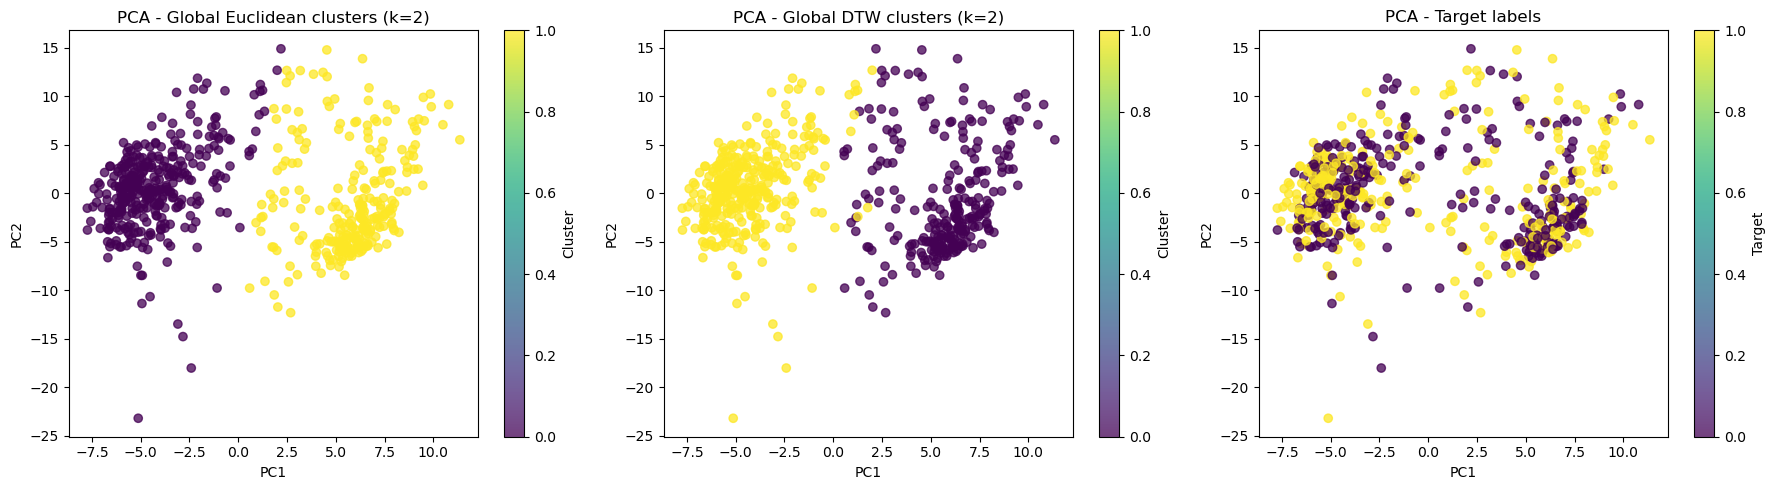

In [39]:
# PCA visualization of global-scaled PAA clustering results

pca = PCA(n_components=2, random_state=random_state)
X_pca_global = pca.fit_transform(X_global_sample_flat)

print("PCA explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter_0 = axes[0].scatter(
    X_pca_global[:, 0],
    X_pca_global[:, 1],
    c=metadata_sample_df["cluster_global_euclidean"],
    alpha=0.75
)
axes[0].set_title(f"PCA - Global Euclidean clusters (k={best_k_global_euclidean})")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.colorbar(scatter_0, ax=axes[0], label="Cluster")

scatter_1 = axes[1].scatter(
    X_pca_global[:, 0],
    X_pca_global[:, 1],
    c=metadata_sample_df["cluster_global_dtw"],
    alpha=0.75
)
axes[1].set_title(f"PCA - Global DTW clusters (k={best_k_global_dtw})")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
fig.colorbar(scatter_1, ax=axes[1], label="Cluster")

scatter_2 = axes[2].scatter(
    X_pca_global[:, 0],
    X_pca_global[:, 1],
    c=metadata_sample_df["target"],
    alpha=0.75
)
axes[2].set_title("PCA - Target labels")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")
fig.colorbar(scatter_2, ax=axes[2], label="Target")

plt.tight_layout()
plt.show()

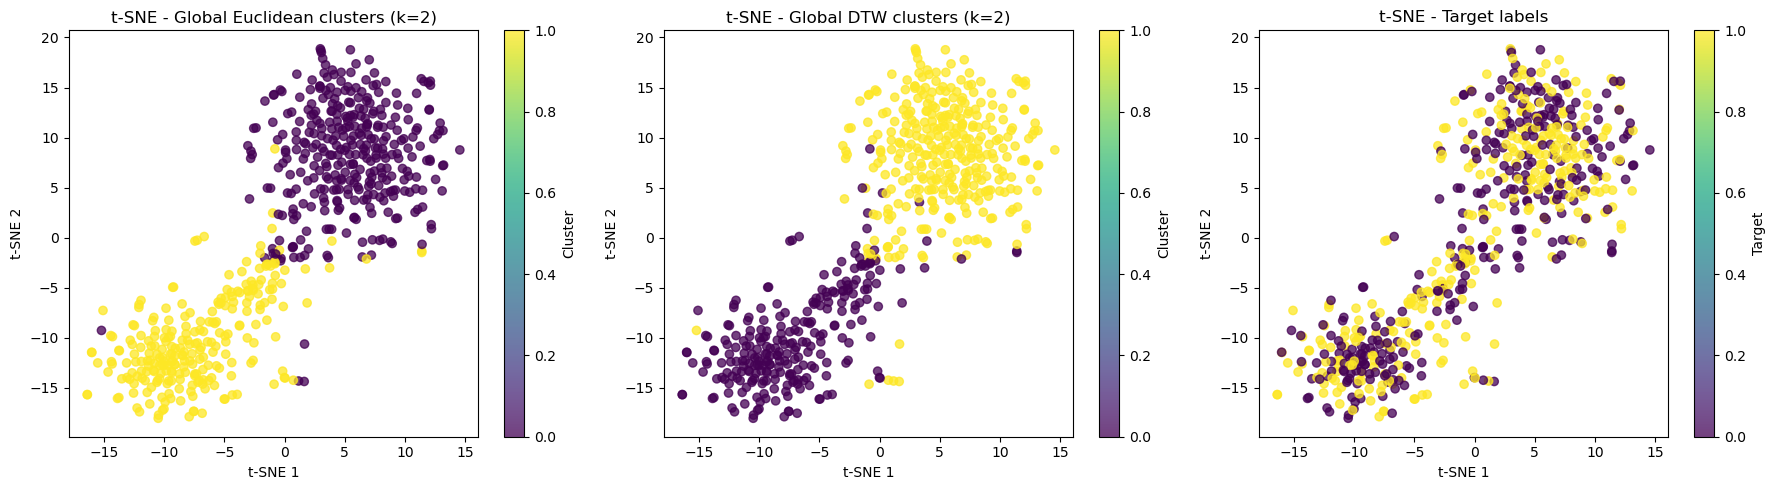

In [40]:
# t-SNE visualization of global-scaled PAA clustering results

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=random_state
)

X_tsne_global = tsne.fit_transform(X_global_sample_flat)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter_0 = axes[0].scatter(
    X_tsne_global[:, 0],
    X_tsne_global[:, 1],
    c=metadata_sample_df["cluster_global_euclidean"],
    alpha=0.75
)
axes[0].set_title(f"t-SNE - Global Euclidean clusters (k={best_k_global_euclidean})")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
fig.colorbar(scatter_0, ax=axes[0], label="Cluster")

scatter_1 = axes[1].scatter(
    X_tsne_global[:, 0],
    X_tsne_global[:, 1],
    c=metadata_sample_df["cluster_global_dtw"],
    alpha=0.75
)
axes[1].set_title(f"t-SNE - Global DTW clusters (k={best_k_global_dtw})")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
fig.colorbar(scatter_1, ax=axes[1], label="Cluster")

scatter_2 = axes[2].scatter(
    X_tsne_global[:, 0],
    X_tsne_global[:, 1],
    c=metadata_sample_df["target"],
    alpha=0.75
)
axes[2].set_title("t-SNE - Target labels")
axes[2].set_xlabel("t-SNE 1")
axes[2].set_ylabel("t-SNE 2")
fig.colorbar(scatter_2, ax=axes[2], label="Target")

plt.tight_layout()
plt.show()

In [41]:
# Evaluate Agglomerative Clustering on globally scaled PAA representation

from sklearn.cluster import AgglomerativeClustering

k_values_agg = [2, 3, 4, 5, 6]

agg_results = []

for k in k_values_agg:
    print(f"Fitting Agglomerative Clustering with k={k}...")
    
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    labels = model.fit_predict(X_global_sample_flat)
    
    sil = silhouette_score(X_global_sample_flat, labels)
    ari = adjusted_rand_score(y_sample, labels)
    nmi = normalized_mutual_info_score(y_sample, labels)
    
    agg_results.append({
        "representation": "global_scaled_PAA_flat",
        "k": k,
        "silhouette": sil,
        "ARI_vs_target": ari,
        "NMI_vs_target": nmi,
        "labels": labels,
        "model": model
    })

agg_results_df = pd.DataFrame([
    {key: value for key, value in row.items() if key not in ["labels", "model"]}
    for row in agg_results
])

display(agg_results_df)

Fitting Agglomerative Clustering with k=2...
Fitting Agglomerative Clustering with k=3...
Fitting Agglomerative Clustering with k=4...
Fitting Agglomerative Clustering with k=5...
Fitting Agglomerative Clustering with k=6...


,representation,k,silhouette,ARI_vs_target,NMI_vs_target
0,global_scaled_PAA_flat,2,0.095370,-0.000947,0.000518
1,global_scaled_PAA_flat,3,0.092893,-0.000915,0.000999
2,global_scaled_PAA_flat,4,0.102633,-0.001203,0.000974
3,global_scaled_PAA_flat,5,0.092285,-0.001353,0.000947
4,global_scaled_PAA_flat,6,0.095483,-0.001356,0.000980


In [42]:
# Select best Agglomerative Clustering result

best_agg_row = agg_results_df.loc[
    agg_results_df["silhouette"].idxmax()
]

best_k_agg = int(best_agg_row["k"])

best_agg_result = next(
    row for row in agg_results
    if row["k"] == best_k_agg
)

agg_labels = best_agg_result["labels"]

metadata_sample_df["cluster_agglomerative"] = agg_labels

print("Best Agglomerative k based on silhouette:", best_k_agg)
display(best_agg_row)

Best Agglomerative k based on silhouette: 4


representation    global_scaled_PAA_flat
k                                      4
silhouette                      0.102633
ARI_vs_target                  -0.001203
NMI_vs_target                   0.000974
Name: 2, dtype: object

In [43]:
# Interpret Agglomerative clusters using target labels

agg_cluster_counts = pd.crosstab(
    metadata_sample_df["cluster_agglomerative"],
    metadata_sample_df["target"]
)

agg_cluster_props = pd.crosstab(
    metadata_sample_df["cluster_agglomerative"],
    metadata_sample_df["target"],
    normalize="index"
)

print("Agglomerative cluster counts by target:")
display(agg_cluster_counts)

print("Agglomerative cluster proportions by target:")
display(agg_cluster_props)

Agglomerative cluster counts by target:


target,0,1
cluster_agglomerative,,
0,146,152
1,13,15
2,88,77
3,53,56


Agglomerative cluster proportions by target:


target,0,1
cluster_agglomerative,,
0,0.489933,0.510067
1,0.464286,0.535714
2,0.533333,0.466667
3,0.486239,0.513761


In [44]:
# Final clustering comparison table

comparison_rows = []

best_global = global_euclidean_results_df.loc[
    global_euclidean_results_df["silhouette"].idxmax()
]
comparison_rows.append({
    "method": "TimeSeriesKMeans",
    "distance": "Euclidean",
    "representation": "global-scaled multivariate PAA",
    "best_k": int(best_global["k"]),
    "silhouette": best_global["silhouette"],
    "ARI_vs_target": best_global["ARI_vs_target"],
    "NMI_vs_target": best_global["NMI_vs_target"]
})

best_global_dtw = global_dtw_results_df.loc[
    global_dtw_results_df["silhouette_flat"].idxmax()
]
comparison_rows.append({
    "method": "TimeSeriesKMeans",
    "distance": "DTW",
    "representation": "global-scaled multivariate PAA",
    "best_k": int(best_global_dtw["k"]),
    "silhouette": best_global_dtw["silhouette_flat"],
    "ARI_vs_target": best_global_dtw["ARI_vs_target"],
    "NMI_vs_target": best_global_dtw["NMI_vs_target"]
})

best_agg = agg_results_df.loc[
    agg_results_df["silhouette"].idxmax()
]
comparison_rows.append({
    "method": "Agglomerative",
    "distance": "Ward/Euclidean",
    "representation": "global-scaled flattened PAA",
    "best_k": int(best_agg["k"]),
    "silhouette": best_agg["silhouette"],
    "ARI_vs_target": best_agg["ARI_vs_target"],
    "NMI_vs_target": best_agg["NMI_vs_target"]
})

clustering_final_comparison_df = pd.DataFrame(comparison_rows)

display(clustering_final_comparison_df)

,method,distance,representation,best_k,silhouette,ARI_vs_target,NMI_vs_target
0,TimeSeriesKMeans,Euclidean,global-scaled multivariate PAA,2,0.122235,-0.001592,0.000033
1,TimeSeriesKMeans,DTW,global-scaled multivariate PAA,2,0.120574,-0.001363,0.000206
2,Agglomerative,Ward/Euclidean,global-scaled flattened PAA,4,0.102633,-0.001203,0.000974


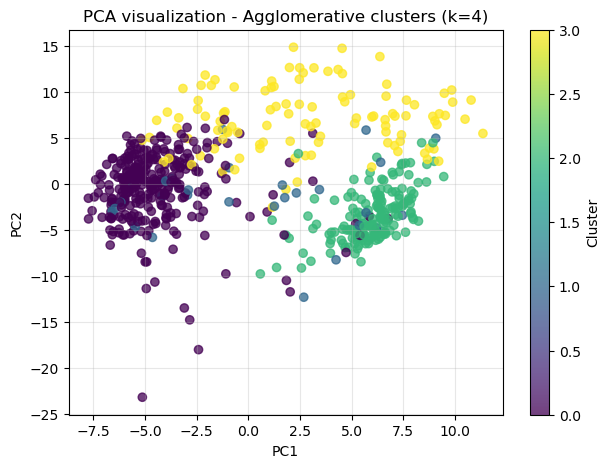

In [45]:
# PCA visualization - Agglomerative clusters

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    X_pca_global[:, 0],
    X_pca_global[:, 1],
    c=metadata_sample_df["cluster_agglomerative"],
    alpha=0.75
)

plt.title(f"PCA visualization - Agglomerative clusters (k={best_k_agg})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)
plt.show()

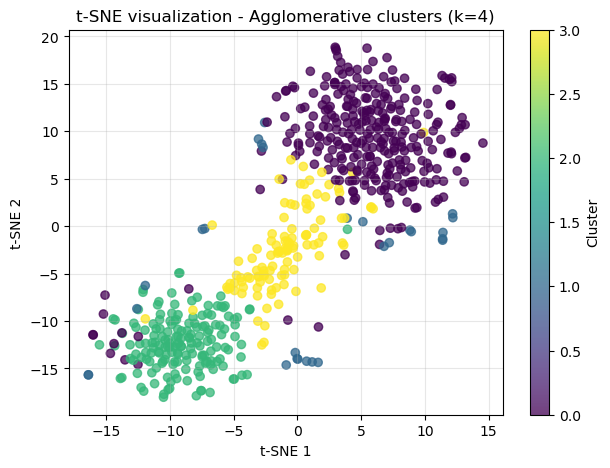

In [46]:
# t-SNE visualization - Agglomerative clusters

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    X_tsne_global[:, 0],
    X_tsne_global[:, 1],
    c=metadata_sample_df["cluster_agglomerative"],
    alpha=0.75
)

plt.title(f"t-SNE visualization - Agglomerative clusters (k={best_k_agg})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)
plt.show()

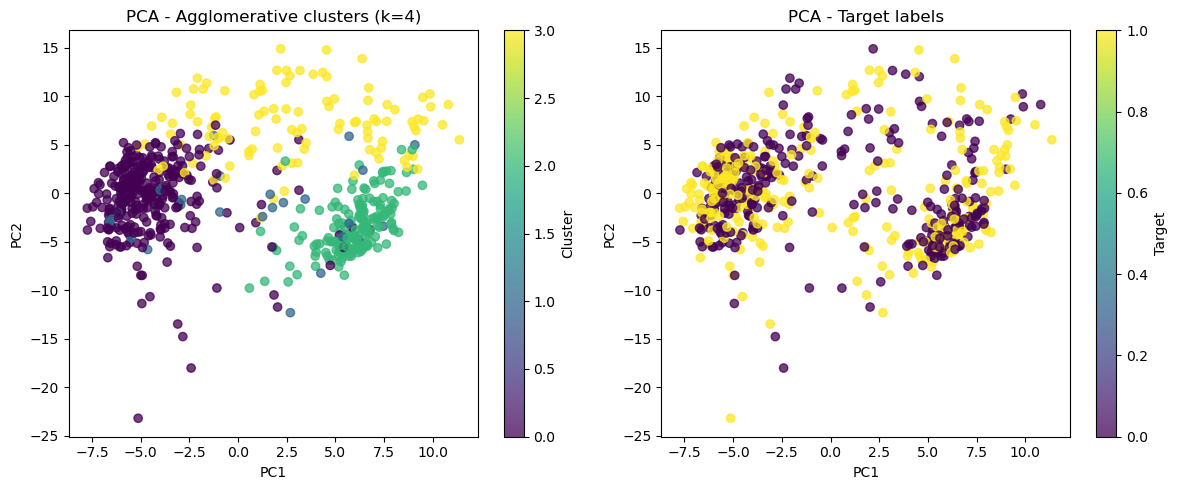

In [47]:
# Side-by-side visualization: Agglomerative clusters vs target labels

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scatter_0 = axes[0].scatter(
    X_pca_global[:, 0],
    X_pca_global[:, 1],
    c=metadata_sample_df["cluster_agglomerative"],
    alpha=0.75
)
axes[0].set_title(f"PCA - Agglomerative clusters (k={best_k_agg})")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.colorbar(scatter_0, ax=axes[0], label="Cluster")

scatter_1 = axes[1].scatter(
    X_pca_global[:, 0],
    X_pca_global[:, 1],
    c=metadata_sample_df["target"],
    alpha=0.75
)
axes[1].set_title("PCA - Target labels")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
fig.colorbar(scatter_1, ax=axes[1], label="Target")

plt.tight_layout()
plt.show()

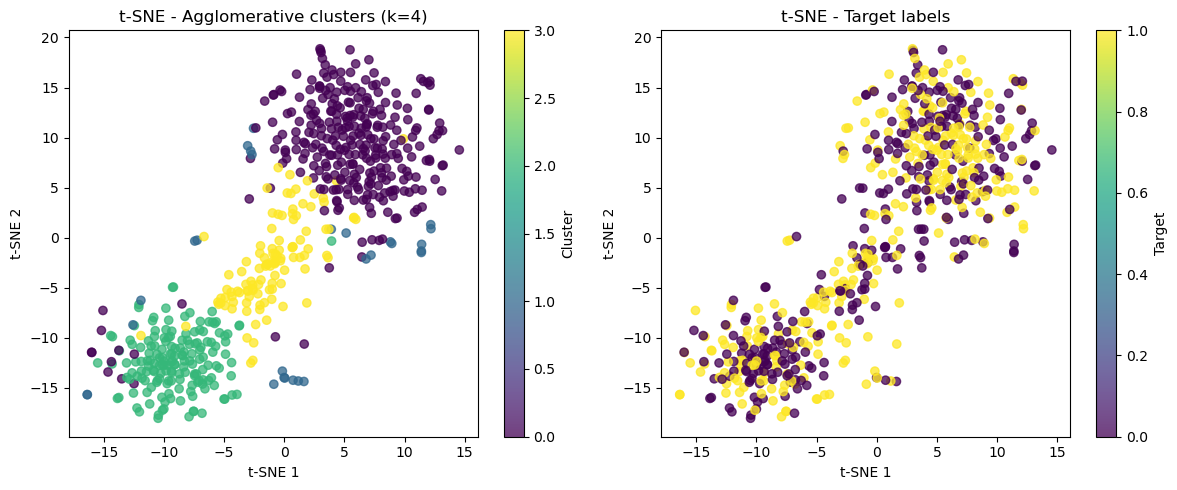

In [48]:
# Side-by-side t-SNE visualization: Agglomerative clusters vs target labels

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scatter_0 = axes[0].scatter(
    X_tsne_global[:, 0],
    X_tsne_global[:, 1],
    c=metadata_sample_df["cluster_agglomerative"],
    alpha=0.75
)
axes[0].set_title(f"t-SNE - Agglomerative clusters (k={best_k_agg})")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
fig.colorbar(scatter_0, ax=axes[0], label="Cluster")

scatter_1 = axes[1].scatter(
    X_tsne_global[:, 0],
    X_tsne_global[:, 1],
    c=metadata_sample_df["target"],
    alpha=0.75
)
axes[1].set_title("t-SNE - Target labels")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
fig.colorbar(scatter_1, ax=axes[1], label="Target")

plt.tight_layout()
plt.show()

In [49]:
# Isomap visualization of clustering results

from sklearn.manifold import Isomap

isomap = Isomap(
    n_components=2,
    n_neighbors=15
)

X_isomap_global = isomap.fit_transform(X_global_sample_flat)

print("Isomap embedding shape:", X_isomap_global.shape)

Isomap embedding shape: (600, 2)


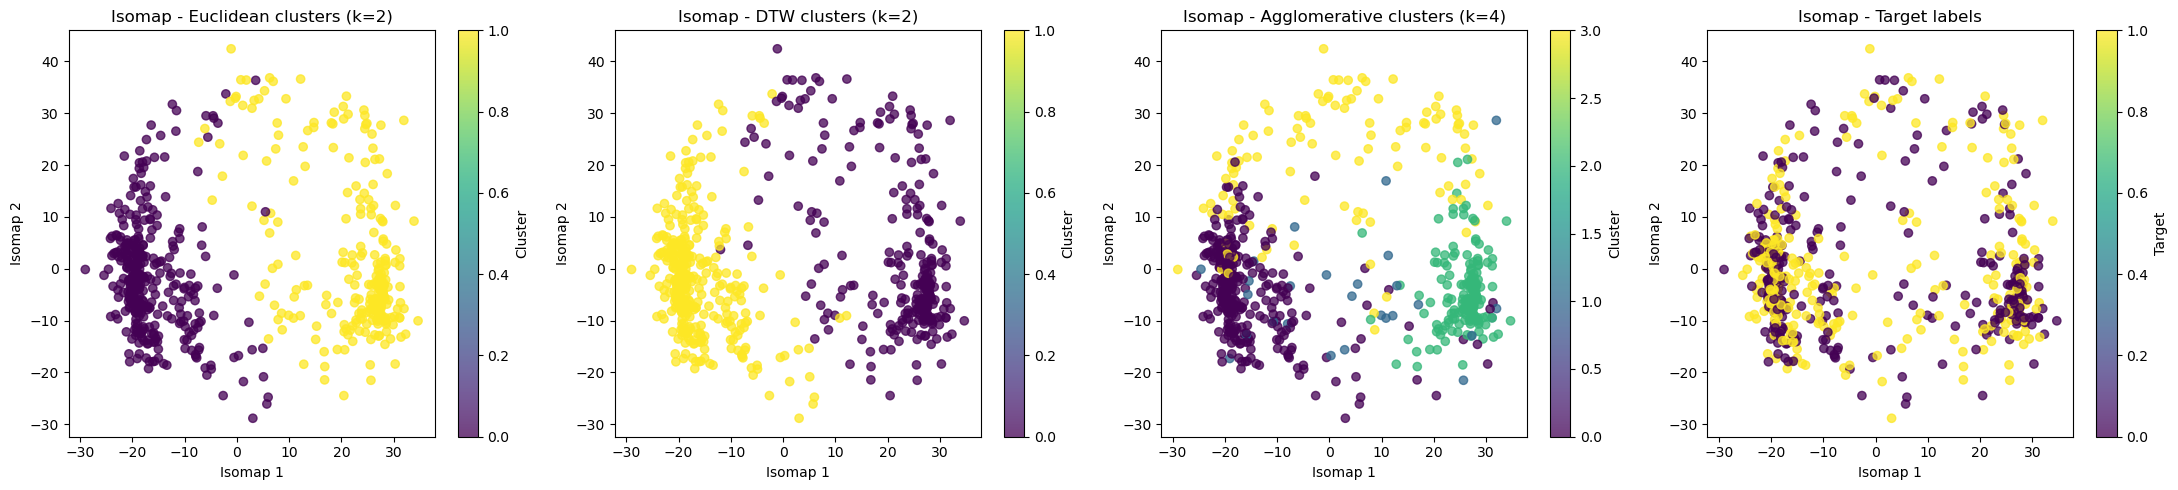

In [50]:
# Isomap visualization: clustering results and target labels

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

scatter_0 = axes[0].scatter(
    X_isomap_global[:, 0],
    X_isomap_global[:, 1],
    c=metadata_sample_df["cluster_global_euclidean"],
    alpha=0.75
)
axes[0].set_title(f"Isomap - Euclidean clusters (k={best_k_global_euclidean})")
axes[0].set_xlabel("Isomap 1")
axes[0].set_ylabel("Isomap 2")
fig.colorbar(scatter_0, ax=axes[0], label="Cluster")

scatter_1 = axes[1].scatter(
    X_isomap_global[:, 0],
    X_isomap_global[:, 1],
    c=metadata_sample_df["cluster_global_dtw"],
    alpha=0.75
)
axes[1].set_title(f"Isomap - DTW clusters (k={best_k_global_dtw})")
axes[1].set_xlabel("Isomap 1")
axes[1].set_ylabel("Isomap 2")
fig.colorbar(scatter_1, ax=axes[1], label="Cluster")

scatter_2 = axes[2].scatter(
    X_isomap_global[:, 0],
    X_isomap_global[:, 1],
    c=metadata_sample_df["cluster_agglomerative"],
    alpha=0.75
)
axes[2].set_title(f"Isomap - Agglomerative clusters (k={best_k_agg})")
axes[2].set_xlabel("Isomap 1")
axes[2].set_ylabel("Isomap 2")
fig.colorbar(scatter_2, ax=axes[2], label="Cluster")

scatter_3 = axes[3].scatter(
    X_isomap_global[:, 0],
    X_isomap_global[:, 1],
    c=metadata_sample_df["target"],
    alpha=0.75
)
axes[3].set_title("Isomap - Target labels")
axes[3].set_xlabel("Isomap 1")
axes[3].set_ylabel("Isomap 2")
fig.colorbar(scatter_3, ax=axes[3], label="Target")

plt.tight_layout()
plt.show()

In [51]:
# Function to plot average cluster profiles for a selected representation

def plot_cluster_profiles(X_data, labels, signal_cols, title_prefix):
    """
    Plot average PAA profile by cluster for each signal.

    X_data shape: n_windows × n_channels × n_time_steps
    """
    unique_clusters = sorted(np.unique(labels))

    for signal_idx, signal in enumerate(signal_cols):
        plt.figure(figsize=(8, 4))

        for cluster in unique_clusters:
            cluster_mean = X_data[labels == cluster, signal_idx, :].mean(axis=0)
            plt.plot(cluster_mean, label=f"Cluster {cluster}")

        plt.title(f"{title_prefix} - average {signal} profile by cluster")
        plt.xlabel("PAA time step")
        plt.ylabel(f"Globally standardized {signal}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

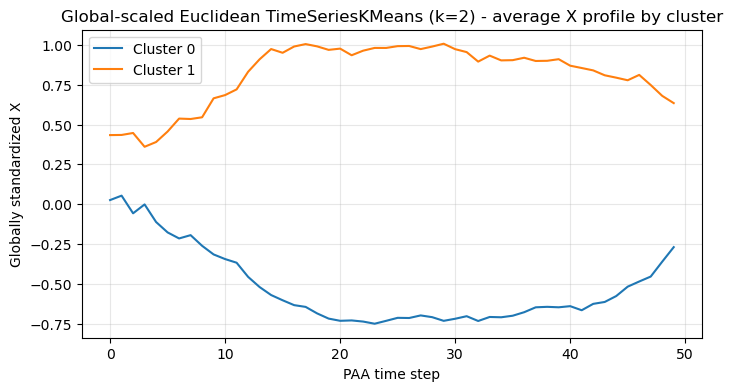

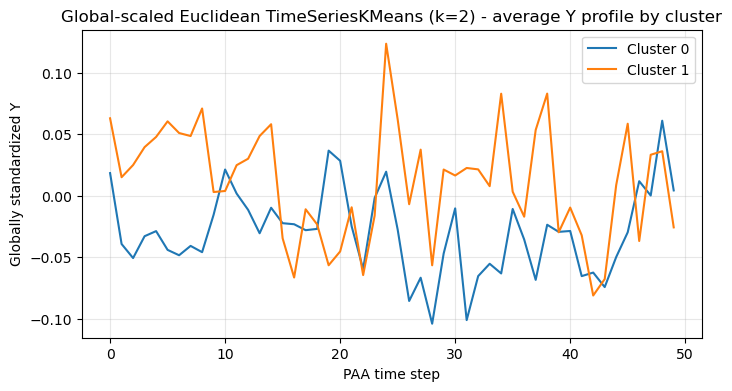

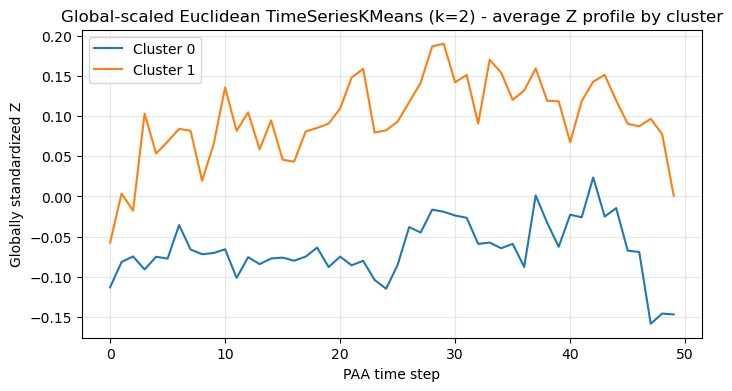

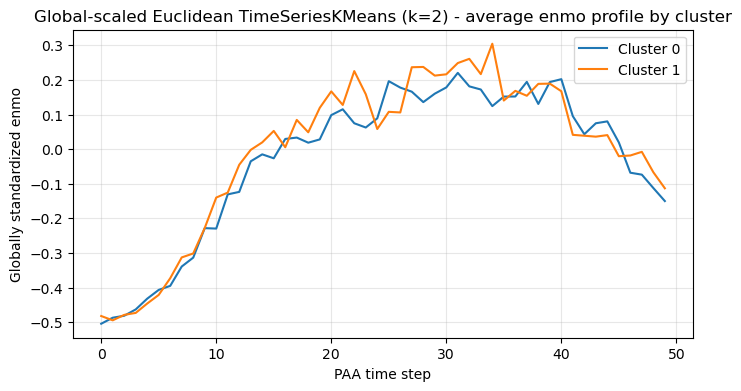

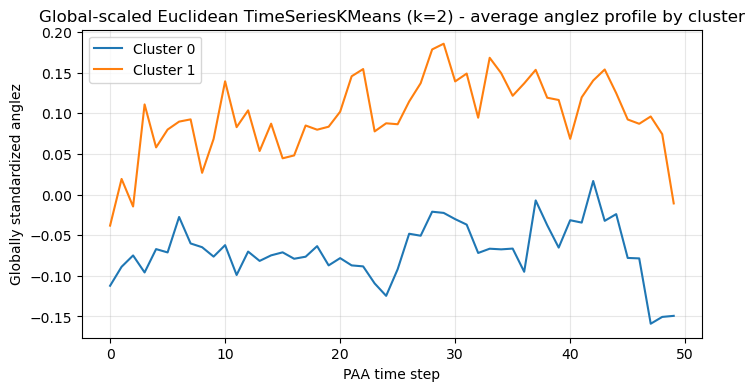

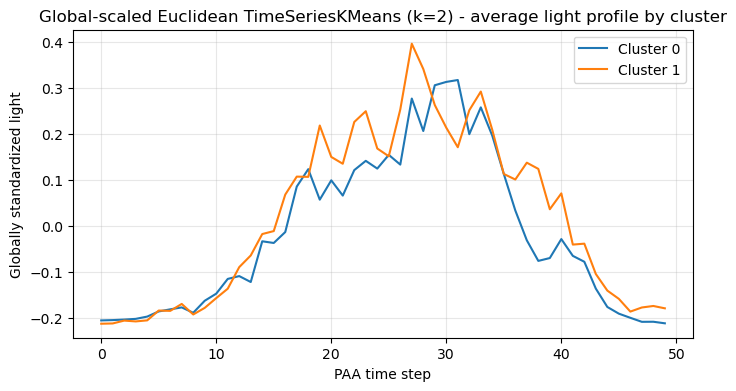

In [52]:
# Average profiles for global-scaled Euclidean clusters

plot_cluster_profiles(
    X_data=X_cluster_global_sample,
    labels=global_euclidean_labels,
    signal_cols=signal_cols,
    title_prefix=f"Global-scaled Euclidean TimeSeriesKMeans (k={best_k_global_euclidean})"
)

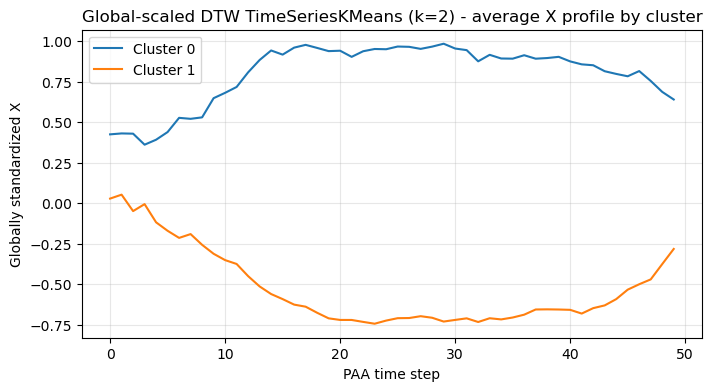

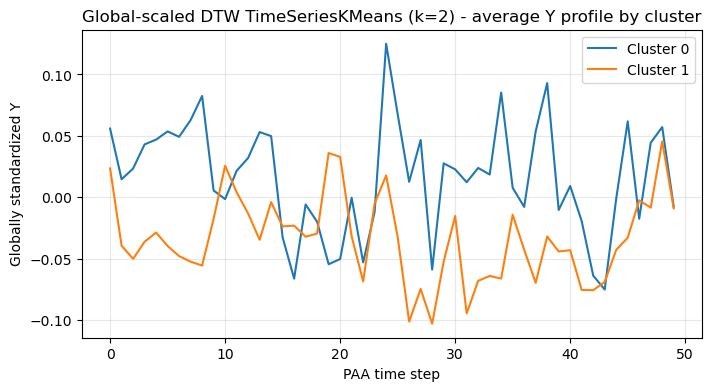

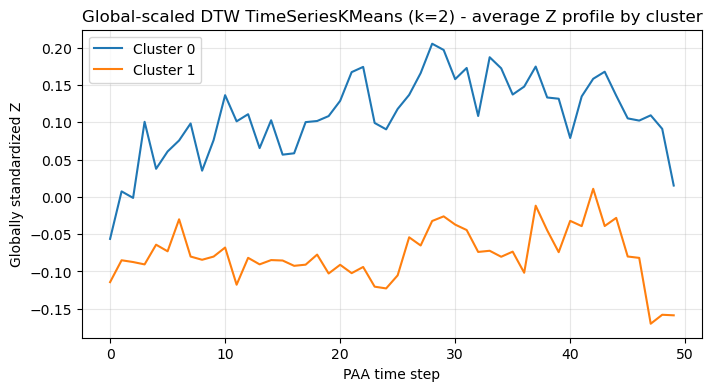

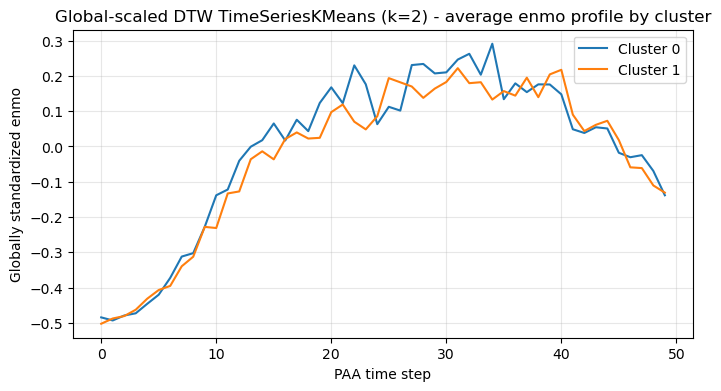

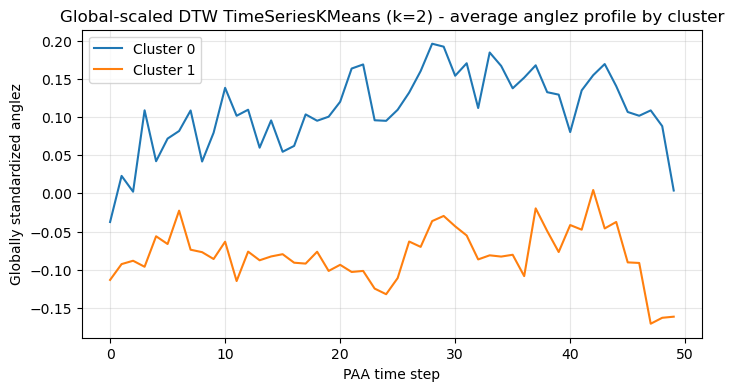

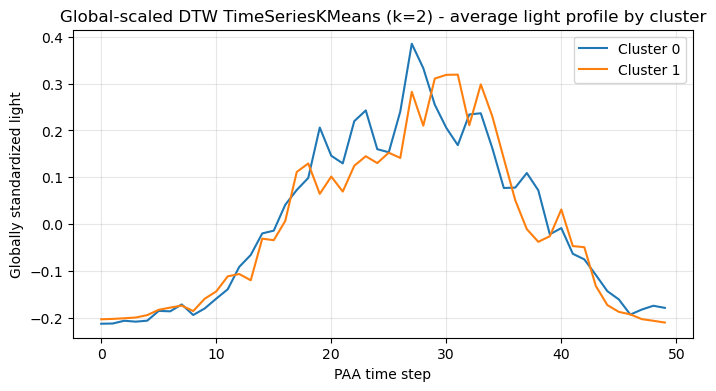

In [53]:
# Average profiles for global-scaled DTW clusters

plot_cluster_profiles(
    X_data=X_cluster_global_sample,
    labels=global_dtw_labels,
    signal_cols=signal_cols,
    title_prefix=f"Global-scaled DTW TimeSeriesKMeans (k={best_k_global_dtw})"
)

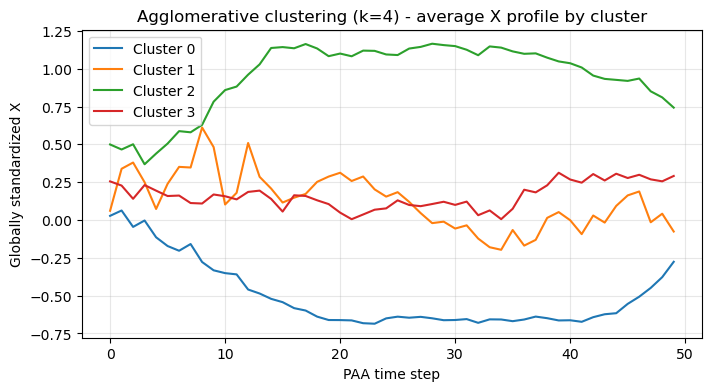

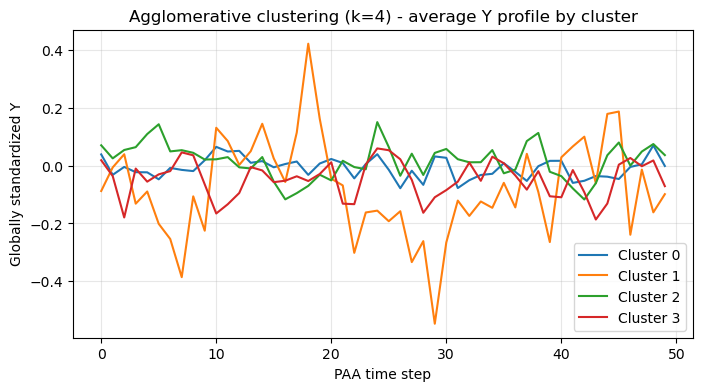

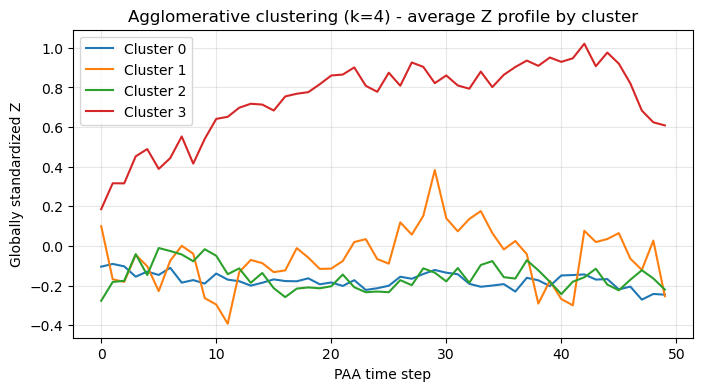

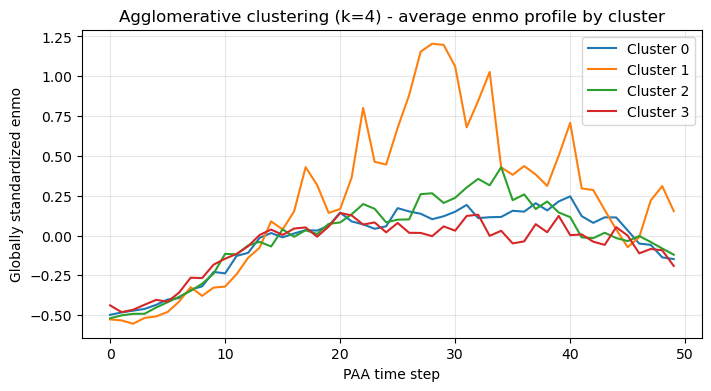

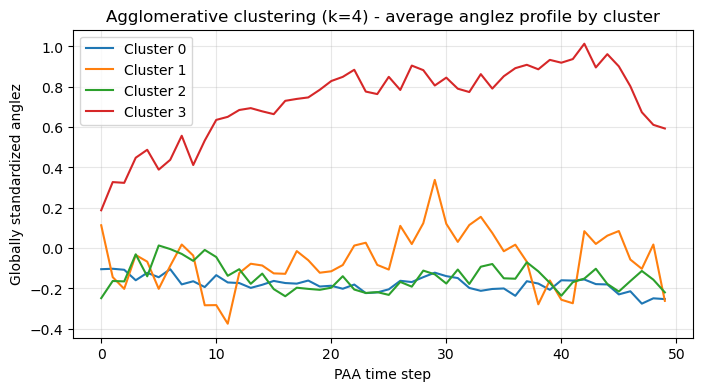

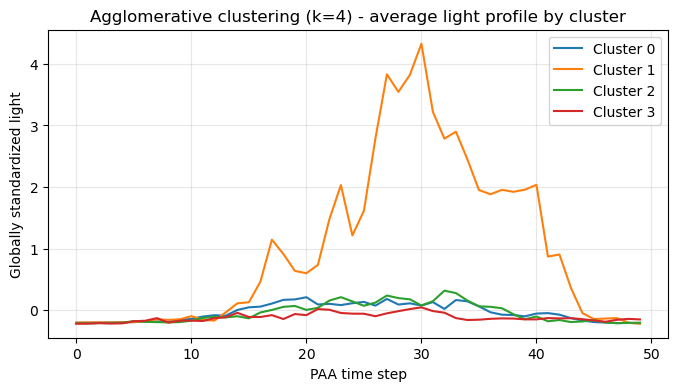

In [54]:
# Average profiles for Agglomerative clusters

plot_cluster_profiles(
    X_data=X_cluster_global_sample,
    labels=agg_labels,
    signal_cols=signal_cols,
    title_prefix=f"Agglomerative clustering (k={best_k_agg})"
)

In [55]:
# Build interpretable time-series descriptors for cluster characterization

from sklearn.linear_model import LinearRegression

def compute_ts_descriptors(X_data, signal_cols):
    """
    Compute interpretable window-level descriptors from multivariate time series.

    X_data shape: n_windows × n_channels × n_time_steps
    """
    rows = []
    n_windows, n_channels, n_time_steps = X_data.shape
    time_index = np.arange(n_time_steps).reshape(-1, 1)

    for i in range(n_windows):
        row = {"sample_index": i}

        for s_idx, signal in enumerate(signal_cols):
            x = X_data[i, s_idx, :].astype(float)

            row[f"{signal}_mean"] = np.mean(x)
            row[f"{signal}_std"] = np.std(x)
            row[f"{signal}_median"] = np.median(x)
            row[f"{signal}_min"] = np.min(x)
            row[f"{signal}_max"] = np.max(x)
            row[f"{signal}_range"] = np.max(x) - np.min(x)
            row[f"{signal}_q25"] = np.quantile(x, 0.25)
            row[f"{signal}_q75"] = np.quantile(x, 0.75)
            row[f"{signal}_iqr"] = np.quantile(x, 0.75) - np.quantile(x, 0.25)

            dx = np.diff(x)
            row[f"{signal}_mean_abs_diff"] = np.mean(np.abs(dx))
            row[f"{signal}_diff_std"] = np.std(dx)

            model = LinearRegression()
            model.fit(time_index, x)
            row[f"{signal}_trend_slope"] = model.coef_[0]

        rows.append(row)

    return pd.DataFrame(rows)


ts_descriptor_df = compute_ts_descriptors(
    X_data=X_cluster_global_sample,
    signal_cols=signal_cols
)

# Add cluster labels and target
ts_descriptor_df["cluster_global_euclidean"] = metadata_sample_df["cluster_global_euclidean"].to_numpy()
ts_descriptor_df["cluster_global_dtw"] = metadata_sample_df["cluster_global_dtw"].to_numpy()
ts_descriptor_df["cluster_agglomerative"] = metadata_sample_df["cluster_agglomerative"].to_numpy()
ts_descriptor_df["target"] = metadata_sample_df["target"].to_numpy()

print("Descriptor dataframe shape:", ts_descriptor_df.shape)
display(ts_descriptor_df.head())

Descriptor dataframe shape: (600, 77)


,sample_index,X_mean,X_std,X_median,X_min,X_max,X_range,X_q25,X_q75,X_iqr,...,light_q25,light_q75,light_iqr,light_mean_abs_diff,light_diff_std,light_trend_slope,cluster_global_euclidean,cluster_global_dtw,cluster_agglomerative,target
0,0,-0.467649,0.596873,-0.681201,-1.153764,1.407762,2.561526,-0.899122,-0.231262,0.667860,...,-0.249836,-0.227469,0.022367,0.023243,0.051752,0.001586,0,1,0,0
1,1,1.093632,0.359266,1.148563,-0.563643,1.800774,2.364416,1.038788,1.280479,0.241692,...,-0.220837,-0.171435,0.049402,0.106579,0.318659,-0.000974,1,0,2,0
2,2,0.273414,0.546606,0.194543,-1.111938,1.774517,2.886455,0.175939,0.510850,0.334911,...,-0.214158,-0.133355,0.080803,0.018712,0.026510,-0.000798,0,1,0,0
3,3,0.981682,0.445615,1.109001,-0.324199,1.780525,2.104724,0.869359,1.270464,0.401105,...,-0.219333,-0.123614,0.095719,0.038704,0.063442,-0.002582,1,0,2,0
4,4,0.141746,0.378881,0.197153,-1.296187,1.392977,2.689164,0.064009,0.209787,0.145778,...,-0.248651,-0.217835,0.030816,0.004491,0.011525,0.000698,0,1,0,1


In [56]:
# Select compact interpretable descriptors for cluster characterization

selected_descriptor_cols = [
    "enmo_mean",
    "enmo_std",
    "enmo_max",
    "enmo_trend_slope",
    "enmo_mean_abs_diff",
    "light_mean",
    "light_std",
    "anglez_mean",
    "anglez_std",
    "X_std",
    "Y_std",
    "Z_std"
]

display(ts_descriptor_df[selected_descriptor_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
enmo_mean,600.0,-0.017670,0.281544,-0.685033,-0.214780,-0.044873,0.138364,1.308323
enmo_std,600.0,0.639284,0.380571,0.000866,0.369102,0.556512,0.799245,2.369275
enmo_max,600.0,2.459329,1.933855,-0.681444,1.060063,1.976499,3.337517,12.965022
enmo_trend_slope,600.0,0.010204,0.012964,-0.022761,0.001903,0.008442,0.015906,0.077586
enmo_mean_abs_diff,600.0,0.399536,0.202675,0.000491,0.260913,0.355156,0.503975,1.358403
light_mean,600.0,-0.001590,0.346122,-0.256319,-0.191700,-0.144573,0.050519,2.263566
light_std,600.0,0.526301,0.683186,0.000000,0.067466,0.188543,0.747685,3.485326
anglez_mean,600.0,0.001398,0.492324,-2.680604,-0.318528,-0.062862,0.249262,1.527788
anglez_std,600.0,0.684568,0.223623,0.235426,0.547499,0.653949,0.772869,2.846502
X_std,600.0,0.579096,0.167154,0.146438,0.460325,0.555637,0.685555,1.143938


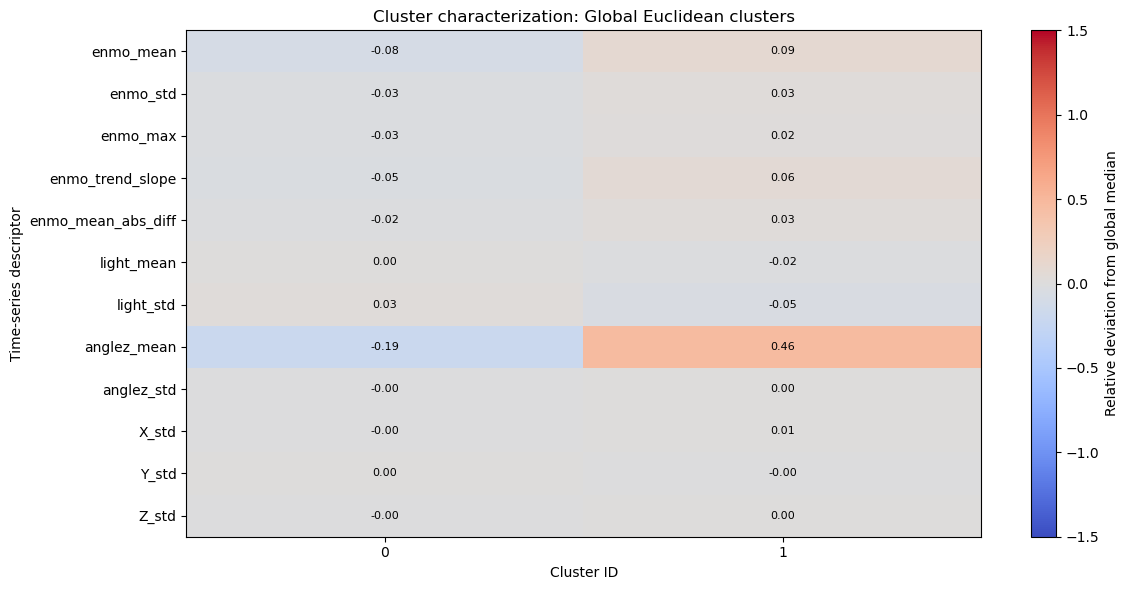

In [57]:
# Function to characterize clusters by relative deviation from the global median

def cluster_relative_median_heatmap(df, cluster_col, feature_cols, title):
    cluster_medians = df.groupby(cluster_col)[feature_cols].median()
    global_median = df[feature_cols].median()

    eps = 1e-8
    relative_diff = (cluster_medians - global_median) / (np.abs(global_median) + eps)

    # Clip extreme values for readability
    relative_diff_clipped = relative_diff.clip(-1.5, 1.5)

    plt.figure(figsize=(12, 6))
    plt.imshow(relative_diff_clipped.T, aspect="auto", cmap="coolwarm", vmin=-1.5, vmax=1.5)
    plt.colorbar(label="Relative deviation from global median")

    plt.xticks(
        ticks=np.arange(relative_diff_clipped.shape[0]),
        labels=relative_diff_clipped.index
    )
    plt.yticks(
        ticks=np.arange(len(feature_cols)),
        labels=feature_cols
    )

    # Annotate cells
    for i in range(relative_diff_clipped.shape[0]):
        for j in range(len(feature_cols)):
            value = relative_diff_clipped.iloc[i, j]
            plt.text(
                i, j,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

    plt.xlabel("Cluster ID")
    plt.ylabel("Time-series descriptor")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return relative_diff


relative_diff_global_euclidean = cluster_relative_median_heatmap(
    df=ts_descriptor_df,
    cluster_col="cluster_global_euclidean",
    feature_cols=selected_descriptor_cols,
    title="Cluster characterization: Global Euclidean clusters"
)

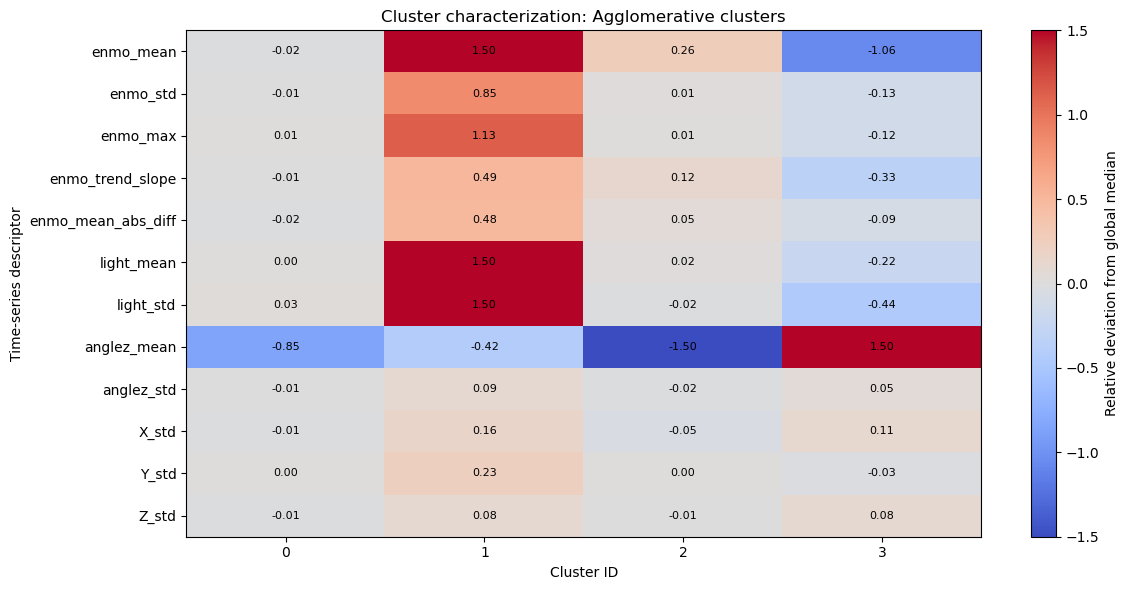

In [58]:
relative_diff_agg = cluster_relative_median_heatmap(
    df=ts_descriptor_df,
    cluster_col="cluster_agglomerative",
    feature_cols=selected_descriptor_cols,
    title="Cluster characterization: Agglomerative clusters"
)

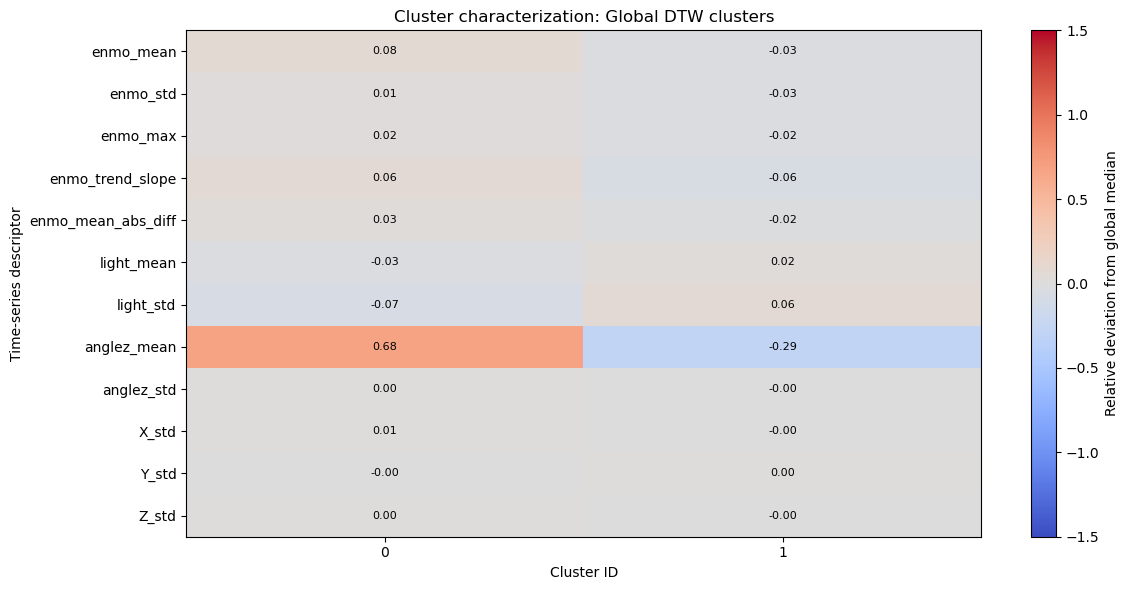

In [59]:
# Cluster characterization heatmap for global-scaled DTW clusters

relative_diff_global_dtw = cluster_relative_median_heatmap(
    df=ts_descriptor_df,
    cluster_col="cluster_global_dtw",
    feature_cols=selected_descriptor_cols,
    title="Cluster characterization: Global DTW clusters"
)